# **Airbnb Prices in Three of Europe's Top Tourist Cities: Paris vs Rome vs Barcelona**
## Exploratory Data Analysis (EDA) : Mini Project

**Project Type:** Exploratory Data Analysis

**Contribution:** Group of 2

**Members:** *Mahnoor*, *Aima Arshad*

## **0. Introduction**

### **0.1 Project Summary**

Airbnb has become one of the most common ways tourists stay in European cities. But what actually decides the price of an Airbnb? Is it the city, the day of the week, how close it is to the centre, the type of room, or the host?

In this project we take Airbnb price data for **three of Europe's most-visited tourist cities: Paris, Rome and Barcelona**, for both **weekday** and **weekend** stays. That gives us **6 separate datasets** (3 cities × 2 day types), which we merge into one table and explore.

We compare the cities on **4 components**:

| # | Component | What we want to know |
|---|---|---|
| 1 | **Price** | Which city is most expensive, and do weekends cost more? |
| 2 | **Location** | Does being close to the centre, metro, attractions and restaurants raise the price? |
| 3 | **Room type & size** | What kind of accommodation does each city offer, and how much does it change the price? |
| 4 | **Hosts & guest satisfaction** | Do Superhosts and business hosts charge more or get better ratings? |

**Rule we follow throughout:** We write our questions and expectations *before* looking at the data, and every chart is followed by an **Observation** explaining what it shows in plain English.

### **0.2 About the Dataset**

- **Where it comes from:** The data was collected by two researchers from the University of Warsaw, **Kristóf Gyódi and Łukasz Nawaro**, for their 2021 research paper *"Determinants of Airbnb prices in European cities: A spatial econometrics approach"*, published in the journal *Tourism Management*.
- **Where we downloaded it:** Kaggle : *"Airbnb Prices in European Cities"* by thedevastator. The original files are also published by the researchers on Zenodo (DOI: 10.5281/zenodo.4446043).
- **What's in it:** 10 European cities, each with a *weekdays* file and a *weekends* file. **We use 3 cities, so 6 files.**

**The most important fact about this dataset:**
The price column `realSum` is **the full price of the stay for 2 people and 2 nights, in euros (EUR)**. Every listing was priced for the *same* booking: 2 guests, 2 nights. This matters a lot later (see Pre-Analysis question PA1).

### **0.3 Why these 3 cities?**

- **All three are among the most-visited tourist cities in Europe**, so Airbnb is a big part of how visitors stay in each of them. That makes the comparison meaningful.
- **All three use the euro**, so prices can be compared directly with no currency conversion.
- **They are different enough to be interesting:**
  - **Paris** is a huge capital city and one of the most expensive destinations in Europe.
  - **Rome** is a historic capital where most attractions are packed into a small old centre.
  - **Barcelona** is a coastal city famous for its strict rules on tourist rentals.
- This lets us ask whether the same things (location, room type, host type) drive prices in the same way in three very different cities.

### **0.4 Problem Statements**

These are the questions this notebook sets out to answer:

**Price**
1. Which of the three cities is the most expensive for an Airbnb stay?
2. Do weekend stays cost more than weekday stays, and is that true in every city?

**Location**

3. Does price go down as you move away from the city centre? Does it matter equally in all three cities?
4. Are listings close to attractions and restaurants more expensive?

**Room type & size**

5. What kind of accommodation dominates each city: entire homes or private rooms?
6. How much more does an entire home cost compared to a private room?

**Hosts & guest satisfaction**

7. Do Superhosts charge more, or do they just get better ratings?
8. Are listings run by "business" hosts (more than 4 listings) rated differently from those run by regular people?
9. Does cleanliness drive overall guest satisfaction?

### **0.5 Variable Dictionary**

Every column in the dataset, explained in plain English. The **Type** column says what *kind* of variable it is, which decides what statistics and charts we can use on it.

| Column | Plain-English meaning | Type |
|---|---|---|
| `Unnamed: 0` | Just a row number left over from when the file was saved. Not real data. | Identifier (to drop) |
| `realSum` | Total price in euros for **2 people staying 2 nights**. Our main variable of interest. | Continuous numeric |
| `room_type` | What you get: the **entire home/apartment**, a **private room** in someone's home, or a **shared room**. | Categorical (3 groups) |
| `room_shared` | True if it is a shared room. | Binary (True/False) |
| `room_private` | True if it is a private room. | Binary (True/False) |
| `person_capacity` | The maximum number of guests the listing allows. | Discrete numeric |
| `host_is_superhost` | True if the host has Airbnb's **"Superhost"** badge, which Airbnb gives to experienced, highly-rated, reliable hosts. | Binary (True/False) |
| `multi` | 1 if the host has **2–4 listings** on Airbnb. | Binary (0/1) |
| `biz` | 1 if the host has **more than 4 listings**, i.e. it is likely a business, not a regular person renting out their home. | Binary (0/1) |
| `cleanliness_rating` | How clean guests rated the place, out of 10. | Ordinal / discrete numeric |
| `guest_satisfaction_overall` | Guests' overall rating of the stay, out of 100. | Ordinal / discrete numeric |
| `bedrooms` | Number of bedrooms. **0 means a studio** (one room with no separate bedroom). | Discrete numeric |
| `dist` | Distance from the city centre, in km. | Continuous numeric |
| `metro_dist` | Distance to the nearest metro station, in km. | Continuous numeric |
| `attr_index` | A score for how attractive the area around the listing is for tourists, built by the researchers from TripAdvisor data on nearby attractions. It is not a simple count: attractions that are more popular and closer to the listing add more to the score. Higher = better location for sightseeing. | Continuous numeric |
| `attr_index_norm` | The same attraction score, **rescaled to 0-100 within each file** (each city's weekday and weekend files are rescaled separately; 100 = the best-located listing *in that file*). | Continuous numeric |
| `rest_index` | The same kind of score for restaurants, built from TripAdvisor data on nearby restaurants. Higher = more (and more popular) restaurants close by. | Continuous numeric |
| `rest_index_norm` | The same restaurant score, rescaled to 0-100 within each file. | Continuous numeric |
| `lng` | Longitude of the listing (east–west position on the map). | Continuous numeric (coordinate) |
| `lat` | Latitude of the listing (north–south position on the map). | Continuous numeric (coordinate) |

**Two columns we will add ourselves during the merge:**

| Column | Meaning |
|---|---|
| `city` | Paris, Rome or Barcelona: which file the row came from. |
| `day_type` | Weekdays or Weekends: which file the row came from. |

### **0.6 Roadmap of this Notebook**

| Section | What happens |
|---|---|
| **1. Pre-Analysis** | Questions and hypotheses written *before* opening any file |
| **2. First Contact** | Load all 6 files separately and inspect them |
| **3. Data Quality** | Missing values, duplicates, data types |
| **4. The Merge** | Combine the 6 files into one table and account for every row |
| **5. Feature Engineering** | Create new, more useful columns |
| **6. Univariate Analysis** | Look at each variable on its own |
| **7. Outlier Investigation** | Statistical vs real-world outliers, and what we decide to do with each |
| **8. The 4 Components** | Price · Location · Room type · Hosts & satisfaction, compared across cities |
| **9. Relationships & Correlation** | Correlation matrix, and a check for Simpson's Paradox |
| **10. Hypothesis Testing** | Proving our main findings with statistical tests, not just charts |
| **11. Leakage & Multicollinearity** | Which columns would cause problems for a future price model |
| **12. Final Report** | Conclusions, limitations and recommended next steps |

### **0.7 Setup: Importing Libraries**

| Library | What we use it for |
|---|---|
| `pandas` | Loading and working with tables of data |
| `numpy` | Maths (e.g. log transformation) |
| `matplotlib` | Basic charts |
| `seaborn` | Nicer statistical charts, built on top of matplotlib |
| `scipy.stats` | Statistical tests (Section 10) |
| `plotly.express` | Interactive map (Section 8) |

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
import os
# Make all charts share one clean style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Give each city ONE fixed colour, used in every chart,
# so the reader can recognise a city instantly without reading the legend
CITY_COLOURS = {"Paris": "#2E86AB", "Rome": "#4C9F70", "Barcelona": "#E4572E"}

# Show all columns when we print a table
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## **1. Pre-Analysis : Before We Open Any File**

Before touching the data, we think about what the columns *mean* in the real world and write down what we expect to find. This stops us from just describing charts after the fact, and it means our findings can genuinely surprise us.

**PA1.** The price column `realSum` is the full price for **2 people and 2 nights**. What kind of measurement is this, and what does the "2 people, 2 nights" rule mean for how we can and cannot use it?

**Answer:**

**It is a continuous numeric variable.** It can take any value (e.g. €187.43), and differences between values are meaningful: €300 is exactly €100 more than €200.

**Because every listing was priced for the same booking (2 guests, 2 nights), all prices are directly comparable.** A studio and a 6-person apartment were both priced for the same 2-person, 2-night stay, so we are comparing like with like.

**What this means for us:**
- **It is not a nightly price.** To get the price per night, we divide by 2. Travellers think in "per night", so we will use this to make our findings easier to understand.
- **It is not a price per person, and we must not divide it by `person_capacity`.** A 6-person apartment was still priced for 2 people, so dividing by 6 would make it look 3 times cheaper per person than it really was for this booking. This would be a real mistake, and a tempting one.
- **Prices for bigger groups aren't in the data.** We can only say what a stay for a couple costs, not what a family of five would pay.

**PA2.** `cleanliness_rating` (out of 10) and `guest_satisfaction_overall` (out of 100) are guest ratings. What kind of measurement are they, and what problems do we expect with them?

**Answer:**

**They are subjective.** They come from guests personal opinions, not from a measurement device.

**They are ordinal.** A higher number means a better experience, but the "distance" between a 7 and an 8 is not necessarily the same as between a 9 and a 10. In practice they are averaged and treated like numbers, just like the Happiness Score was.

**Expected problem i.e rating inflation:** On Airbnb, most guests give very high ratings, and many only give low ratings when something went seriously wrong. So we expect:
- Most ratings bunched up near the top (9–10 out of 10, 90–100 out of 100).
- A long tail of a few low ratings.
- A rating of 90/100 may actually be *below average* on Airbnb, even though it sounds excellent.
- Because everything is bunched near the top, ratings may not show strong relationships with other variables, since there isn't much variation to work with.

**PA3.** We want to combine the weekday and weekend files. Can we match the same listing across both files, like we matched countries in the Happiness × HDI lab?

**Answer:**

**No.** To match rows across two tables (a *merge* or *join*), both tables need a shared **key** column that identifies the same thing in both, like `Country` in the Happiness × HDI lab.

Our files have **no listing ID or listing name**. Each row only has its features and its map coordinates. So we can't say "this apartment cost €200 on a weekday and €240 on the weekend".

**What we do instead:** we **stack** the files on top of each other (`pd.concat`) and add two labels, `city` and `day_type`, so we always know where each row came from. Then we compare the **groups** as a whole, e.g. the typical weekend price vs the typical weekday price.

**Could we match on coordinates (`lat`, `lng`)?** It is tempting, but risky: Airbnb deliberately shifts the displayed location of listings slightly for privacy, and two different apartments in the same building can have nearly the same coordinates. A match could easily pair up the wrong listings, so we don't do it.

**PA4.** `attr_index_norm` and `rest_index_norm` are rescaled to 0-100 **within each file** (each city's weekday and weekend files are rescaled separately). What does this mean for comparing cities?

**Answer:**

It means **100 = the best-located listing in *that* file** (that city and day type), not in all of Europe.

So a Paris listing with `attr_index_norm = 80` and a Rome listing with `attr_index_norm = 80` are *both* "very well located for their own city". That does **not** mean they have the same number of attractions nearby. One city may simply have far more attractions overall.

**What this means for us:**
- We **can** compare the *effect* of location across cities, e.g. "does price rise with `attr_index_norm` more steeply in Paris than in Rome?"
- We **cannot** say "Paris listings have better access to attractions than Rome listings" by comparing the normalised numbers directly.
- The raw columns (`attr_index`, `rest_index`) are not rescaled, but their scale also depends on how many TripAdvisor places each city has, so they are not a clean cross-city comparison either.

**PA5.** Write down hypotheses we expect the data to confirm, and one we expect it to challenge. Each must have a clear direction.

**Answer:**

**Hypotheses we expect the data to CONFIRM:**

**H1. Weekend stays will cost more than weekday stays in all three cities.**
Reason: More tourists travel on weekends, so demand is higher, and hosts raise prices.

**H2. Price will go down as distance from the city centre goes up, in all three cities** (a negative relationship).

Reason: The centre is where most attractions, restaurants and transport are, so central locations are more in demand.

**H3. Entire homes/apartments will cost more than private rooms, which will cost more than shared rooms, in every city.**

Reason: You get more space and more privacy.

**H4. Paris will be the most expensive of the three cities.**

Reason: It is one of the most expensive cities in Europe in general (housing, hotels, daily costs), and hosts' prices should reflect that.

**Hypothesis we expect the data to CHALLENGE:**

**H5. "Superhosts charge noticeably more than regular hosts."**

We expect this to be weak or false. The Superhost badge is about **service** (quick replies, few cancellations, good reviews), not about having a **luxury** property. So we expect Superhosts to have clearly **higher ratings**, but only a **small or no price difference**.

*We will come back to each of these hypotheses in the Final Report and say whether the data confirmed or rejected it.*

---
## **2. First Contact: Inspect Before We Merge**

Before combining anything, we load each of the 6 files **separately** and inspect them. If one file had different columns, different data types or strange values, merging first would hide the problem inside one big table. Checking each file on its own lets us catch it early.

### **2.1 Connecting to Google Drive and loading the files**

**Step 1: Mount Google Drive.** Our CSV files are stored in a Google Drive folder. We **mount** (connect) Google Drive to Colab so the notebook can read the files directly. Files uploaded straight into Colab are deleted when the session ends, but files in Drive stay permanently, so the notebook works every time it is opened.

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


**See what is inside the dataset folder.**

`os.listdir()` lists every file inside a folder. `sorted()` puts them in alphabetical order so they are easier to read.

In [5]:
folder_path = "/content/drive/MyDrive/NIAI py 1/EDA Project/airbnbDatasets"

all_files = sorted(os.listdir(folder_path))
print(f"Found {len(all_files)} files:")
for file in all_files:
    print(file)

Found 20 files:
amsterdam_weekdays.csv
amsterdam_weekends.csv
athens_weekdays.csv
athens_weekends.csv
barcelona_weekdays.csv
barcelona_weekends.csv
berlin_weekdays.csv
berlin_weekends.csv
budapest_weekdays.csv
budapest_weekends.csv
lisbon_weekdays.csv
lisbon_weekends.csv
london_weekdays.csv
london_weekends.csv
paris_weekdays.csv
paris_weekends.csv
rome_weekdays.csv
rome_weekends.csv
vienna_weekdays.csv
vienna_weekends.csv


**Observation:** The folder contains **20 files**: 10 European cities (Amsterdam, Athens, Barcelona, Berlin, Budapest, Lisbon, London, Paris, Rome, Vienna), each with a weekdays file and a weekends file. **We use only 6 of them**, the weekdays and weekends files for Paris, Rome and Barcelona, for the reasons explained in Section 0.3.

### **2.2 Load our 6 files**

**How the code works:**
- `cities` and `days` are two lists. Looping through both gives us all 6 combinations (paris_weekdays, paris_weekends, rome_weekdays, and so on).
- `f"{city}_{day}"` is an **f-string**: it builds the file name by filling in the city and day, e.g. `"paris_weekdays"`.
- `os.path.join()` joins the folder path and the file name into one full path, adding the `/` between them correctly.
- We store each loaded table in a **dictionary** called `files`, where the key is the file name and the value is the table. This keeps all 6 tables organised under one name instead of 6 separate variables.
- `.shape` gives (rows, columns).

In [6]:
cities = ["paris", "rome", "barcelona"]
days = ["weekdays", "weekends"]

files = {}
for city in cities:
    for day in days:
        name = f"{city}_{day}"
        file_path = os.path.join(folder_path, f"{name}.csv")
        files[name] = pd.read_csv(file_path)
        print(f"{name}: {files[name].shape[0]} rows, {files[name].shape[1]} columns")

total_rows = sum(len(df) for df in files.values())
print("\nTotal rows across all 6 files:", total_rows)

paris_weekdays: 3130 rows, 20 columns
paris_weekends: 3558 rows, 20 columns
rome_weekdays: 4492 rows, 20 columns
rome_weekends: 4535 rows, 20 columns
barcelona_weekdays: 1555 rows, 20 columns
barcelona_weekends: 1278 rows, 20 columns

Total rows across all 6 files: 18548


**Observations:**

| File | Rows |
|---|---|
| paris_weekdays | 3,130 |
| paris_weekends | 3,558 |
| rome_weekdays | 4,492 |
| rome_weekends | 4,535 |
| barcelona_weekdays | 1,555 |
| barcelona_weekends | 1,278 |
| **Total** | **18,548** |

- Every file has **20 columns**.
- **Rome is by far the biggest city in our data:** 9,027 rows, which is about **49%** of everything. Paris has 6,688 rows (36%) and Barcelona only 2,833 (15%).
- **Why this matters:** if we calculate one overall average for all rows combined, Rome will dominate it just because it has the most listings. So we will always compare **city by city**, not just look at combined numbers.
- Paris has more weekend listings than weekday listings, but Barcelona has fewer. So the number of listings is not the same in both files of a city.

**Do all 6 files have the same columns?**

Stacking files on top of each other only works if they have the **same columns in the same order**. We use `paris_weekdays` as the reference and compare every other file against it.

In [ ]:
reference_columns = list(files["paris_weekdays"].columns)

for name, df in files.items():
    same = list(df.columns) == reference_columns
    print(f"{name}: same columns as paris_weekdays? {same}")

**Observation:** All 6 files return `True`. They have exactly the same 20 columns in the same order, so it is safe to stack them in Section 4 without renaming or rearranging anything.

### **2.3 Data types**

Each column has a **data type** that tells Python how to treat it: numbers, text, or True/False. We check the types in one file, then confirm all 6 files match.

In [7]:
reference_types = files["paris_weekdays"].dtypes

for name, df in files.items():
    print(f"{name}: same data types? {df.dtypes.equals(reference_types)}")

reference_types

paris_weekdays: same data types? True
paris_weekends: same data types? True
rome_weekdays: same data types? True
rome_weekends: same data types? True
barcelona_weekdays: same data types? True
barcelona_weekends: same data types? True


,0
Unnamed: 0,int64
realSum,float64
room_type,object
room_shared,bool
room_private,bool
person_capacity,float64
host_is_superhost,bool
multi,int64
biz,int64
cleanliness_rating,float64


**Observations:**

- All 6 files have identical data types.
- `room_type` is stored as **text** (`object`), which is correct since it is a category.
- **Yes/No information is stored in two different ways:** `room_shared`, `room_private` and `host_is_superhost` use **True/False** (`bool`), while `multi` and `biz` use **1/0** (`int64`). Both mean the same thing, but it is an inconsistency in how the dataset was built. It does not break anything, but it is worth knowing.
- `person_capacity`, `cleanliness_rating` and `guest_satisfaction_overall` are stored as **decimals** (`float64`), even though every value in them is a whole number (e.g. `4.0`, not `4.3`). This is because the CSV file stores them as "4.0". We will convert them to whole numbers in Section 4.
- `Unnamed: 0` is stored as a number, but it is only the row number (0, 1, 2, ...), not real information.

### **2.4 Looking at the first 10 rows of each city**

Before running any statistics, we just **read** the raw data, the same way we did in the Happiness × HDI lab. We look at the weekday file of each city. These are **observations, not conclusions**.

In [8]:
files["paris_weekdays"].head(10)

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,296.159940,Private room,False,True,2.0,True,0,0,10.0,97.0,1,0.699821,0.193709,518.478947,25.239380,1218.662228,71.608028,2.35385,48.86282
1,1,288.237487,Private room,False,True,2.0,True,0,0,10.0,97.0,1,2.100005,0.107221,873.216962,42.507907,1000.543327,58.791463,2.32436,48.85902
2,2,211.343089,Private room,False,True,2.0,False,0,0,10.0,94.0,1,3.302325,0.234724,444.556077,21.640840,902.854467,53.051310,2.31714,48.87475
3,3,298.956100,Entire home/apt,False,False,2.0,False,0,1,9.0,91.0,1,0.547567,0.195997,542.142014,26.391291,1199.184166,70.463506,2.35600,48.86100
4,4,247.926181,Entire home/apt,False,False,4.0,False,0,0,7.0,82.0,1,1.197921,0.103573,406.928958,19.809165,1070.775497,62.918272,2.35915,48.86648
5,5,527.076149,Entire home/apt,False,False,4.0,True,0,0,10.0,93.0,1,1.543201,0.549130,967.478112,47.096508,1095.870434,64.392839,2.33201,48.85891
6,6,193.634076,Private room,False,True,2.0,False,0,0,10.0,90.0,1,3.998176,0.415838,422.895629,20.586417,803.434049,47.209413,2.30670,48.87582
7,7,207.148849,Entire home/apt,False,False,2.0,False,0,0,10.0,95.0,1,1.425279,0.207387,374.367762,18.224096,1018.159360,59.826572,2.36075,48.86825
8,8,345.092739,Entire home/apt,False,False,2.0,False,0,1,9.0,94.0,0,1.771036,0.210693,623.192130,30.336783,1358.637365,79.832902,2.33543,48.86767
9,9,741.448411,Entire home/apt,False,False,3.0,False,0,1,10.0,91.0,1,0.973833,0.155017,650.586755,31.670344,1372.589175,80.652704,2.34467,48.86352


In [9]:
files["rome_weekdays"].head(10)

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,156.874664,Private room,False,True,2.0,True,1,0,10.0,95.0,1,2.978468,1.595733,281.163932,6.230648,697.727246,15.191486,12.48654,41.92498
1,1,172.772543,Private room,False,True,2.0,False,1,0,9.0,80.0,1,0.935371,0.649269,482.707193,10.696887,1251.524333,27.249208,12.49627,41.90801
2,2,277.745307,Entire home/apt,False,False,4.0,False,0,1,9.0,90.0,1,2.203025,0.494697,691.708998,15.328408,1625.897266,35.400361,12.47700,41.90700
3,3,444.906834,Entire home/apt,False,False,6.0,False,1,0,9.0,92.0,2,2.703010,1.295153,805.592641,17.852092,2035.819533,44.325522,12.46969,41.90019
4,4,131.391298,Private room,False,True,3.0,False,1,0,9.0,91.0,1,1.295968,0.867455,317.076369,7.026475,836.622814,18.215634,12.51544,41.89463
5,5,182.124237,Entire home/apt,False,False,4.0,False,1,0,9.0,89.0,2,1.285514,0.865180,317.986025,7.046633,840.469083,18.299378,12.51535,41.89470
6,6,117.597550,Private room,False,True,2.0,False,0,1,9.0,90.0,1,1.883320,0.203033,245.979377,5.450952,700.310645,15.247734,12.51798,41.91309
7,7,184.462161,Entire home/apt,False,False,3.0,False,0,0,9.0,92.0,1,4.239363,0.508939,384.678607,8.524554,968.640080,21.090021,12.45359,41.91250
8,8,147.522970,Private room,False,True,2.0,True,0,0,9.0,94.0,1,3.380054,0.605921,599.657458,13.288528,1467.702192,31.956009,12.46183,41.90463
9,9,186.566292,Entire home/apt,False,False,2.0,False,0,1,10.0,96.0,0,5.684160,0.989826,242.612050,5.376331,560.589073,12.205602,12.43471,41.90940


In [10]:
files["barcelona_weekdays"].head(10)

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,474.317499,Entire home/apt,False,False,4.0,False,0,1,10.0,91.0,1,1.111996,0.630491,526.469420,17.942927,915.587083,20.154890,2.17556,41.39624
1,1,169.897829,Private room,False,True,2.0,True,1,0,10.0,88.0,1,1.751839,0.124017,320.127526,10.910462,794.277350,17.484489,2.14906,41.38714
2,2,161.984779,Private room,False,True,4.0,False,0,1,9.0,88.0,1,1.670493,0.080322,344.073936,11.726595,840.673617,18.505814,2.15357,41.37859
3,3,367.956804,Entire home/apt,False,False,3.0,False,0,1,10.0,91.0,1,1.475847,0.093107,400.057449,13.634603,946.589884,20.837357,2.16839,41.37390
4,4,196.895292,Private room,False,True,3.0,False,1,0,9.0,91.0,1,1.855452,0.272486,346.042245,11.793678,792.296039,17.440874,2.15238,41.37699
5,5,330.951661,Entire home/apt,False,False,3.0,False,0,1,9.0,100.0,2,2.565611,0.701290,391.087402,13.328889,525.513902,11.568178,2.18197,41.40842
6,6,141.271208,Private room,False,True,3.0,False,0,1,9.0,86.0,1,1.648304,0.089427,342.596843,11.676253,820.926568,18.071120,2.15342,41.37912
7,7,173.388880,Private room,False,True,2.0,False,0,0,9.0,96.0,1,1.474228,0.590519,448.405616,15.282387,752.758876,16.570540,2.18195,41.39691
8,8,225.754649,Private room,False,True,4.0,False,1,0,9.0,84.0,1,0.962655,0.356134,791.873746,26.988334,1885.534627,41.506420,2.17742,41.38050
9,9,150.580678,Private room,False,True,2.0,False,1,0,9.0,91.0,1,1.819600,0.285601,361.199210,12.310252,806.236687,17.747751,2.15700,41.37400


**Observations:**

**Paris:**
1. Prices in the first 10 rows range from about €194 to €741 for 2 nights, clearly higher than the other two cities' first rows.
2. 6 of the 10 listings are entire homes/apartments. One of them has **0 bedrooms** (a studio) and still costs €345.
3. `rest_index_norm` is quite high (47 to 81) while `attr_index_norm` is much lower (18 to 47), even for the same listings.

**Rome:**
1. Prices are lower, from about €118 to €445. The most expensive one is the biggest: 6 guests and 2 bedrooms.
2. `attr_index_norm` values are very small (5 to 18), even though the listings are only 1 to 6 km from the centre.
3. 5 of the 10 listings belong to hosts with 2 to 4 listings (`multi = 1`).

**Barcelona:**
1. **7 of the 10 listings are private rooms**, not entire homes, unlike Paris.
2. 5 of the 10 belong to "business" hosts with more than 4 listings (`biz = 1`).
3. One listing has a **perfect satisfaction score of 100** but a cleanliness rating of 9, so the two ratings don't always move together.

**All cities:**
- The `lat` and `lng` values match each city's real location on the map (Paris about 48.9°N 2.3°E, Rome about 41.9°N 12.5°E, Barcelona about 41.4°N 2.2°E). This confirms the files are not mislabelled.
- Most ratings are 9 or 10 out of 10, which is the "rating inflation" we predicted in PA2.

### **2.5 Quick range check of each file**

Looking at the **smallest, middle and largest** values of the most important columns in each file helps us spot anything strange before we merge.

**How the code works:** for each file we build a small dictionary of numbers (minimum price, median price, and so on), collect them in a list, and turn that list into a table with `pd.DataFrame`. `.round(1)` keeps one decimal place so the table is easy to read.

In [11]:
summary = []
for name, df in files.items():
    summary.append({
        "file": name,
        "rows": len(df),
        "min_price": df["realSum"].min(),
        "median_price": df["realSum"].median(),
        "max_price": df["realSum"].max(),
        "max_dist_km": df["dist"].max(),
        "max_bedrooms": df["bedrooms"].max(),
        "min_cleanliness": df["cleanliness_rating"].min(),
        "min_satisfaction": df["guest_satisfaction_overall"].min(),
    })

pd.DataFrame(summary).round(1)

,file,rows,min_price,median_price,max_price,max_dist_km,max_bedrooms,min_cleanliness,min_satisfaction
0,paris_weekdays,3130,92.7,318.5,16445.6,7.7,5,2.0,20.0
1,paris_weekends,3558,95.3,316.2,4188.4,7.7,5,2.0,20.0
2,rome_weekdays,4492,46.1,179.8,2418.3,9.4,4,2.0,20.0
3,rome_weekends,4535,46.1,184.5,2311.7,9.6,5,2.0,20.0
4,barcelona_weekdays,1555,69.6,208.5,6943.7,8.4,6,2.0,20.0
5,barcelona_weekends,1278,81.0,204.7,6942.8,8.4,6,2.0,20.0


**Observations:**

1. **One extreme price in Paris:** the most expensive Paris weekday listing costs **€16,445.6 for 2 nights**, about **50 times** the Paris median (€318.5). The second most expensive Paris weekday listing costs about €4,185, so this one listing is about 4 times higher than anything else. It could be a real luxury property or a data error. We flag it for Section 7 (Outliers).

2. **The same listing appears in both Barcelona files:** the most expensive Barcelona listing is almost identical in the weekday file (€6,943.7) and the weekend file (€6,942.8). When we looked closer, both rows have the **same coordinates, same ratings, 1 bedroom and 2 guests**. So it is the **same apartment**, and many other listings also appear in both files of a city. This means our weekday and weekend groups are **not completely separate listings**, which matters for the statistical tests in Section 10.

3. **That Barcelona listing looks suspicious:** €6,943 for 2 nights for a 1-bedroom apartment, 4.5 km from the centre, with a below-average rating of 84/100. Flagged for Section 7.

4. **Median prices:** Paris is highest (about €316 to €319), then Barcelona (about €205 to €209), then Rome (about €180 to €185). At first glance, weekday and weekend medians differ by only a few euros in each city. This is only a first look, and we analyse it properly in Section 8.

5. **Low ratings do exist:** every file has at least one listing with a cleanliness rating of **2/10** and an overall satisfaction of **20/100**. So ratings are mostly high, but not always.

6. **Distances:** all listings are within about 10 km of their city centre, so the data covers the city itself, not the wider region.

### **2.6 How is `attr_index_norm` actually calculated?**

In Observation 2 above, the same Barcelona apartment had the **same** `attr_index` in both files but a **different** `attr_index_norm` (7.44 on weekdays, 8.43 on weekends). If it is the same apartment, why would its normalised score change?

Our guess: the normalised score is `attr_index ÷ (largest attr_index in that file) × 100`. If each file has a different largest value, the same apartment gets a different normalised score. We test this guess.

**How the code works:** we calculate the formula ourselves and compare it to the column in the data. `np.allclose()` checks whether two sets of numbers are equal, allowing for tiny rounding differences in the last decimal places.

In [12]:
for name, df in files.items():
    calc_attr = df["attr_index"] / df["attr_index"].max() * 100
    calc_rest = df["rest_index"] / df["rest_index"].max() * 100
    print(f"{name}: attr formula matches? {np.allclose(calc_attr, df['attr_index_norm'])}, "
          f"rest formula matches? {np.allclose(calc_rest, df['rest_index_norm'])}")

paris_weekdays: attr formula matches? True, rest formula matches? True
paris_weekends: attr formula matches? True, rest formula matches? True
rome_weekdays: attr formula matches? True, rest formula matches? True
rome_weekends: attr formula matches? True, rest formula matches? True
barcelona_weekdays: attr formula matches? True, rest formula matches? True
barcelona_weekends: attr formula matches? True, rest formula matches? True


**Observation:** The formula matches exactly in all 6 files. So:

- `attr_index_norm` = `attr_index` ÷ (largest `attr_index` **in that file**) × 100, and the same for `rest_index_norm`.
- The rescaling is done **per file**, not per city. That is why the same apartment has slightly different normalised scores on weekdays and weekends.
- **It also explains why Rome's scores looked so low in 3.4:** if the single best-located listing in Rome has a very high raw score, everyone else gets divided by that big number and ends up with a small percentage.
- **`attr_index` and `attr_index_norm` contain the same information** (one is just the other multiplied by a fixed number within each file). The same is true for `rest_index` and `rest_index_norm`. This is **redundancy**, and we come back to it in Section 11 (Leakage & Multicollinearity).

---
## **3. Data Quality: Can We Trust This Data?**

Before analysing anything, we check whether the data is **complete** (no missing values), **unique** (no repeated rows), **consistent** (columns don't contradict each other) and **valid** (no impossible values like negative prices). We still check each file separately.

### **3.1 Missing values**

`df.isna()` marks every empty cell as True, and `.sum()` counts them for each column. We do this for all 6 files at once and show the result as one table: **rows = columns of the data, columns = the 6 files**.

In [13]:
missing_table = pd.DataFrame({name: df.isna().sum() for name, df in files.items()})
missing_table["total_missing"] = missing_table.sum(axis=1)
missing_table

,paris_weekdays,paris_weekends,rome_weekdays,rome_weekends,barcelona_weekdays,barcelona_weekends,total_missing
Unnamed: 0,0,0,0,0,0,0,0
realSum,0,0,0,0,0,0,0
room_type,0,0,0,0,0,0,0
room_shared,0,0,0,0,0,0,0
room_private,0,0,0,0,0,0,0
person_capacity,0,0,0,0,0,0,0
host_is_superhost,0,0,0,0,0,0,0
multi,0,0,0,0,0,0,0
biz,0,0,0,0,0,0,0
cleanliness_rating,0,0,0,0,0,0,0


**Observation:** Every value in the table is **0**. There are **no missing values in any column of any file**. This is unusual for real-world data, and it is because the researchers already cleaned the data for their paper. **We do not need to fill in (impute) or drop anything.**

### **3.2 Does "no missing values" mean nothing is missing?**

In the Happiness × HDI lab we learned three types of missing data:

| Type | Meaning | Simple example |
|---|---|---|
| **MCAR** (Missing Completely At Random) | Missing for no reason at all | A survey form got lost by accident |
| **MAR** (Missing At Random) | Missing because of **another column** we can see | New listings have no rating yet, and we have a column showing how new they are |
| **MNAR** (Missing Not At Random) | Missing because of **the missing value itself** | Very bad listings are removed from the website, so their bad ratings never appear |

Our table has no empty cells, but data can also be missing at the level of **whole rows**: listings that never made it into the dataset at all. We check one clue: the smallest `person_capacity`.

In [14]:
for name, df in files.items():
    print(f"{name}: smallest person_capacity = {df['person_capacity'].min()}")

paris_weekdays: smallest person_capacity = 2.0
paris_weekends: smallest person_capacity = 2.0
rome_weekdays: smallest person_capacity = 2.0
rome_weekends: smallest person_capacity = 2.0
barcelona_weekdays: smallest person_capacity = 2.0
barcelona_weekends: smallest person_capacity = 2.0


**Observation:** The smallest capacity in every file is **2**. There is **not a single listing for 1 person**, even though many exist on Airbnb in real life.

**Why?** The researchers searched Airbnb for a stay for **2 guests**. A listing that allows only 1 guest can't be booked for 2 people, so it never appeared in their search results. These listings are missing **because of their own value** (capacity = 1), so this is closest to **MNAR**, also called **selection bias**.

It is also likely that listings **without any reviews** (e.g. brand new ones) were not included, because every listing in our data has a rating. We cannot prove this from the data alone, but it would be the same kind of missingness.

**What this means for us:** our findings describe **listings that can host at least 2 guests** (and probably have reviews). We should not claim they apply to every Airbnb listing in these cities. This goes into our list of limitations.

### **3.3 Duplicate rows**

`df.duplicated()` marks a row as True if an **identical** row appeared earlier in the same file. We check twice:
1. **With** `Unnamed: 0`
2. **Without** `Unnamed: 0`

**Why the second check?** `Unnamed: 0` is a row number, so it is different in every row. Two rows that are exact copies of each other would still look "different" because of their row numbers. Removing that column first shows us the **real** duplicates.

In [15]:
for name, df in files.items():
    with_row_number = df.duplicated().sum()
    without_row_number = df.drop(columns="Unnamed: 0").duplicated().sum()
    print(f"{name}: duplicates = {with_row_number}, duplicates ignoring row number = {without_row_number}")

paris_weekdays: duplicates = 0, duplicates ignoring row number = 0
paris_weekends: duplicates = 0, duplicates ignoring row number = 0
rome_weekdays: duplicates = 0, duplicates ignoring row number = 0
rome_weekends: duplicates = 0, duplicates ignoring row number = 0
barcelona_weekdays: duplicates = 0, duplicates ignoring row number = 0
barcelona_weekends: duplicates = 0, duplicates ignoring row number = 0


**Observation:** **0 duplicates in every file**, both with and without the row number. Nothing needs to be removed.

**Important difference:** in Section 2.5 we found the **same apartment** in both the Barcelona weekday and weekend files. That is **not** a duplicate. It is the same apartment offered for **two different bookings** (a weekday stay and a weekend stay), each with its own price. Both rows are real data, so we keep both.

### **3.4 Consistency checks**

Some columns should follow logical rules. If any rule is broken, part of the data is wrong. We check:

1. `room_shared` should be True **only** when `room_type` is "Shared room".
2. `room_private` should be True **only** when `room_type` is "Private room".
3. `multi` (2 to 4 listings) and `biz` (more than 4 listings) should **never both be 1**. A host can't have 2 to 4 listings and more than 4 at the same time.
4. Prices should be above 0.
5. Distances can't be negative.
6. Cleanliness must be between 0 and 10, and satisfaction between 0 and 100.

**How the code works:**
- `==` compares two columns row by row and gives True/False for each row.
- `&` means "and": both conditions must be True.
- `.all()` asks "is it True for **every** row?" and `.any()` asks "is it True for **at least one** row?"
- `not` flips the answer, so `not (...).any()` means "this **never** happens".
- `.between(0, 10)` checks that each value lies from 0 to 10.

In [16]:
checks = []
for name, df in files.items():
    checks.append({
        "file": name,
        "room_shared matches room_type": (df["room_shared"] == (df["room_type"] == "Shared room")).all(),
        "room_private matches room_type": (df["room_private"] == (df["room_type"] == "Private room")).all(),
        "multi and biz never both 1": not ((df["multi"] == 1) & (df["biz"] == 1)).any(),
        "all prices > 0": (df["realSum"] > 0).all(),
        "no negative distances": ((df["dist"] >= 0) & (df["metro_dist"] >= 0)).all(),
        "cleanliness 0 to 10": df["cleanliness_rating"].between(0, 10).all(),
        "satisfaction 0 to 100": df["guest_satisfaction_overall"].between(0, 100).all(),
    })

pd.DataFrame(checks)

,file,room_shared matches room_type,room_private matches room_type,multi and biz never both 1,all prices > 0,no negative distances,cleanliness 0 to 10,satisfaction 0 to 100
0,paris_weekdays,True,True,True,True,True,True,True
1,paris_weekends,True,True,True,True,True,True,True
2,rome_weekdays,True,True,True,True,True,True,True
3,rome_weekends,True,True,True,True,True,True,True
4,barcelona_weekdays,True,True,True,True,True,True,True
5,barcelona_weekends,True,True,True,True,True,True,True


**Observations:** Every check is **True** in all 6 files. The data follows all the logical rules.

Two of these results lead to decisions:

- **`room_shared` and `room_private` match `room_type` perfectly.** They carry **no new information**; they are just True/False copies of `room_type`. Keeping them would mean storing the same information three times. **Decision: drop them in Section 4.**

- **`multi` and `biz` are never both 1.** So every host falls into exactly one of three groups:
  - `multi = 0` and `biz = 0`: **1 listing** (a regular person)
  - `multi = 1`: **2 to 4 listings**
  - `biz = 1`: **more than 4 listings** (a business)

  **Decision: in Section 5 we combine them into one easy-to-read column called `host_type`.**

### **3.5 Checking the categories and counts**

In the Happiness × HDI lab, country names were written differently in the two datasets ("encoding inconsistencies"). Here we check whether `room_type` is written consistently in every file (no typos, no "entire home" vs "Entire Home"), and which values the count columns take.

`.unique()` lists each different value once. `.tolist()` turns it into a normal Python list so it prints neatly, and `sorted()` puts it in order.

In [17]:
for name, df in files.items():
    print(name)
    print("   room_type:      ", sorted(df["room_type"].unique().tolist()))
    print("   person_capacity:", sorted(df["person_capacity"].unique().tolist()))
    print("   bedrooms:       ", sorted(df["bedrooms"].unique().tolist()))

paris_weekdays
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedrooms:        [0, 1, 2, 3, 4, 5]
paris_weekends
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedrooms:        [0, 1, 2, 3, 4, 5]
rome_weekdays
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedrooms:        [0, 1, 2, 3, 4]
rome_weekends
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedrooms:        [0, 1, 2, 3, 4, 5]
barcelona_weekdays
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedrooms:        [0, 1, 2, 3, 4, 6]
barcelona_weekends
   room_type:       ['Entire home/apt', 'Private room', 'Shared room']
   person_capacity: [2.0, 3.0, 4.0, 5.0, 6.0]
   bedroom

**Observations:**
- `room_type` has exactly **3 values** in every file, spelled identically: "Entire home/apt", "Private room", "Shared room". **No encoding problems**, so when we stack the files, each category will be grouped correctly.
- `person_capacity` is always between **2 and 6**. The minimum of 2 matches what we found in 4.2.
- `bedrooms` goes from **0 (studio) to 6**. Rome has no listing with more than 5 bedrooms, and Barcelona has the largest at 6.

### **3.6 Are the very low ratings errors?**

In Section 2.5 we saw ratings as low as **2/10** for cleanliness and **20/100** for satisfaction. Are these mistakes? We look at which values the satisfaction score actually takes, starting from the lowest.

**How the code works:** `pd.concat(files.values())` stacks all 6 files **only for this quick count**. The proper merge, with city and day labels, happens in Section 4. `.value_counts()` counts how many times each value appears, and `.sort_index()` sorts them from lowest to highest score.

In [18]:
all_rows = pd.concat(files.values())
all_rows["guest_satisfaction_overall"].value_counts().sort_index().head(12)

,count
guest_satisfaction_overall,
20.0,44
40.0,30
50.0,12
53.0,5
54.0,1
55.0,2
56.0,3
57.0,2
60.0,146


**Observation:** The lowest scores are **20**, **40** and **60**, and they appear much more often than the values around them (e.g. 20 appears 44 times, but nothing between 20 and 40 appears).

**Why?** Airbnb guests give ratings as **1 to 5 stars**. Converted to a score out of 100, 1 star = 20, 2 stars = 40, 3 stars = 60. So **20/100 is the lowest possible score (1 star)**, not an error. These exact round values most likely come from listings with **very few reviews**, where one guest's star rating becomes the whole score. The same logic applies to cleanliness out of 10, where 2/10 = 1 star.

**Decision:** the low ratings are **real, valid values**. We keep them.

### **3.7 Data Quality Summary and Decisions**

| Check | What we found | Decision |
|---|---|---|
| Missing values | None in any file | Nothing to impute or drop |
| Hidden missingness | No 1-guest listings (search was for 2 guests); probably no listings without reviews | Keep as a **limitation**: results apply to listings for 2+ guests |
| Duplicate rows | None, even ignoring the row number | Nothing to remove |
| Same listing in weekday and weekend files | Real data, two different bookings | Keep both; mention the overlap in Section 10 |
| `Unnamed: 0` | Only a row number | Drop in Section 4 |
| `room_shared`, `room_private` | Exact copies of `room_type` | Drop in Section 4 |
| `multi` and `biz` | Never both 1 | Combine into `host_type` in Section 5 |
| Whole numbers stored as decimals | `person_capacity`, ratings | Convert to integers in Section 4 |
| `room_type` spelling | Identical in all files | No fix needed |
| Low ratings (20/100, 2/10) | Equal to 1 star, so valid | Keep |
| Extreme prices (€16,445 in Paris) | Found in Section 2.5 | Investigate in Section 7 |

**Overall:** the data is very clean. The main issues are **redundant columns** and **how the sample was chosen**, not errors.

---
## **4. The Merge**

In this section we combine the 6 files into **one table**. As explained in Section 1 (PA3), our files have no listing ID, so we cannot *join* them by matching rows. Instead we **stack** them on top of each other using `pd.concat`.

After stacking, we can no longer tell which file a row came from, so before stacking we add two **label columns** to every row:
- `city`: Paris, Rome or Barcelona
- `day_type`: Weekdays or Weekends

**Q4.1 Before merging, how many rows and columns should the combined table have?**

**Answer:**
- **Rows:** stacking puts every row of every file into the new table, and no rows are matched or removed. So the rows should equal the total of all 6 files: **18,548** (from Section 2.2).
- **Columns:** all 6 files have the same **20** columns (checked in Section 2.2). We add 2 label columns, so we expect **22**.

Predicting first lets us check that the merge worked exactly as intended.

**Q4.2 Stack the 6 files and label each row with its city and day type.**

**How the code works:**
- We loop through the `files` dictionary from Section 2.
- `name.split("_")` splits a file name at the underscore, so "paris_weekdays" gives `city = "paris"` and `day = "weekdays"`.
- `.copy()` makes a copy of the table, so adding new columns doesn't change the original tables in `files`.
- `.title()` capitalises the first letter ("paris" becomes "Paris") so the labels look neat in charts.
- Each labelled table is added to the list `frames`.
- `pd.concat(frames)` stacks all 6 tables into one. `ignore_index=True` gives the new table fresh row numbers (0 to 18,547); otherwise each file's old row numbers would repeat.

In [19]:
frames = []
for name, df in files.items():
    city, day = name.split("_")
    temp = df.copy()
    temp["city"] = city.title()
    temp["day_type"] = day.title()
    frames.append(temp)

airbnb = pd.concat(frames, ignore_index=True)
print("Shape after merge:", airbnb.shape)

Shape after merge: (18548, 22)


**Answer:** The shape is **(18548, 22)**: exactly the rows and columns we predicted in Q4.1.

**Q4.3 Is every row accounted for?**

Matching the total isn't enough on its own; we also check that **each** city and day type kept all of its rows. `groupby(["city", "day_type"]).size()` counts the rows in each city and day type combination.

In [20]:
print(airbnb.groupby(["city", "day_type"]).size())
print("\nSame total as the 6 original files?", len(airbnb) == total_rows)

city       day_type
Barcelona  Weekdays    1555
           Weekends    1278
Paris      Weekdays    3130
           Weekends    3558
Rome       Weekdays    4492
           Weekends    4535
dtype: int64

Same total as the 6 original files? True


**Answer:**

| City | Weekdays | Weekends |
|---|---|---|
| Barcelona | 1,555 | 1,278 |
| Paris | 3,130 | 3,558 |
| Rome | 4,492 | 4,535 |

Every group has exactly the same number of rows as its original file, and the total is still 18,548. **No rows were lost.**

**Comparison with the Happiness × HDI lab:** there, the inner join **lost countries** because some names didn't match between the two datasets (e.g. different spellings). Here, stacking doesn't match anything, so no rows can be lost to mismatches.

**Q4.4 Clean the merged table using the decisions from Section 3.**

**Columns we drop, and why:**
- `Unnamed: 0`: only a row number from the original files. After stacking, the same numbers repeat in every file (each file starts from 0), so it means nothing.
- `room_shared` and `room_private`: in Section 3.4 we proved they are exact True/False copies of `room_type`. Keeping them would store the same information three times.

**Columns we convert, and why:**
- `person_capacity`, `cleanliness_rating` and `guest_satisfaction_overall` are stored as decimals (e.g. `4.0`), but they only ever hold whole numbers (Section 2.3). `.astype(int)` converts them to whole numbers, which matches what they really are: counts and scores.

In [21]:
airbnb = airbnb.drop(columns=["Unnamed: 0", "room_shared", "room_private"])

for col in ["person_capacity", "cleanliness_rating", "guest_satisfaction_overall"]:
    airbnb[col] = airbnb[col].astype(int)

print("Final shape:", airbnb.shape)
airbnb.head()

Final shape: (18548, 19)


,realSum,room_type,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,city,day_type
0,296.159940,Private room,2,True,0,0,10,97,1,0.699821,0.193709,518.478947,25.239380,1218.662228,71.608028,2.35385,48.86282,Paris,Weekdays
1,288.237487,Private room,2,True,0,0,10,97,1,2.100005,0.107221,873.216962,42.507907,1000.543327,58.791463,2.32436,48.85902,Paris,Weekdays
2,211.343089,Private room,2,False,0,0,10,94,1,3.302325,0.234724,444.556077,21.640840,902.854467,53.051310,2.31714,48.87475,Paris,Weekdays
3,298.956100,Entire home/apt,2,False,0,1,9,91,1,0.547567,0.195997,542.142014,26.391291,1199.184166,70.463506,2.35600,48.86100,Paris,Weekdays
4,247.926181,Entire home/apt,4,False,0,0,7,82,1,1.197921,0.103573,406.928958,19.809165,1070.775497,62.918272,2.35915,48.86648,Paris,Weekdays


**Q4.5 Final check: are the data types correct now?**

`.info()` shows every column with its data type and how many non-empty values it has.

In [22]:
airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18548 entries, 0 to 18547
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   realSum                     18548 non-null  float64
 1   room_type                   18548 non-null  object 
 2   person_capacity             18548 non-null  int64  
 3   host_is_superhost           18548 non-null  bool   
 4   multi                       18548 non-null  int64  
 5   biz                         18548 non-null  int64  
 6   cleanliness_rating          18548 non-null  int64  
 7   guest_satisfaction_overall  18548 non-null  int64  
 8   bedrooms                    18548 non-null  int64  
 9   dist                        18548 non-null  float64
 10  metro_dist                  18548 non-null  float64
 11  attr_index                  18548 non-null  float64
 12  attr_index_norm             18548 non-null  float64
 13  rest_index                  185

**Answer:**
- The table now has **18,548 rows and 19 columns** (22 minus the 3 we dropped).
- `person_capacity`, `cleanliness_rating` and `guest_satisfaction_overall` are now whole numbers (`int64`).
- Every column shows **18,548 non-null** values, so there are still no missing values after the merge.
- `city` and `day_type` are text columns, which is correct since they are labels.

This `airbnb` table is the one we use for the rest of the notebook.

---
## **5. Feature Engineering: Creating More Useful Columns**

**Feature engineering** means creating new columns from existing ones to make the data easier to analyse and understand. We create three:

| New column | Built from | Why |
|---|---|---|
| `price_per_night` | `realSum` | Travellers think in "per night", not "per 2 nights" |
| `host_type` | `multi`, `biz` | One readable column instead of two 0/1 columns |
| `dist_band` | `dist` | Groups listings by how far they are from the centre |

### **5.1 Price per night**

**Q5.1 How do we get a nightly price, and why don't we calculate price per person?**

**Answer:** `realSum` is the total for **2 nights**, so dividing it by 2 gives the price per night. This makes our findings easier to understand: "€150 a night" means more to a reader than "€300 for 2 nights".

We do **not** calculate price per person (`realSum ÷ person_capacity`). Every listing was priced for **2 guests** (Section 1, PA1), so dividing a 6-person apartment's price by 6 would make it look 3 times cheaper than it really was for this booking.

In [23]:
airbnb["price_per_night"] = airbnb["realSum"] / 2

airbnb[["city", "realSum", "price_per_night"]].head()

,city,realSum,price_per_night
0,Paris,296.159940,148.079970
1,Paris,288.237487,144.118744
2,Paris,211.343089,105.671544
3,Paris,298.956100,149.478050
4,Paris,247.926181,123.963091


**Observation:** `price_per_night` is exactly half of `realSum` in every row, as expected. From now on we mostly talk about prices **per night**, and we use `realSum` when a calculation needs the original column.

### **5.2 Host type**

**Q5.2 How do we turn `multi` and `biz` into one column?**

In Section 3.4 we proved that `multi` and `biz` are **never both 1**, so every host fits into exactly one group:

| `multi` | `biz` | Meaning | `host_type` |
|---|---|---|---|
| 0 | 0 | Host has only 1 listing (a regular person) | "1 listing" |
| 1 | 0 | Host has 2 to 4 listings | "2-4 listings" |
| 0 | 1 | Host has more than 4 listings (a business) | "5+ listings" |

**How the code works:** we write a small function that looks at one row and returns the right label. `.apply(..., axis=1)` runs this function on **every row** of the table (`axis=1` means "row by row").

In [24]:
def get_host_type(row):
    if row["biz"] == 1:
        return "5+ listings"
    elif row["multi"] == 1:
        return "2-4 listings"
    else:
        return "1 listing"

airbnb["host_type"] = airbnb.apply(get_host_type, axis=1)

airbnb["host_type"].value_counts()

,count
host_type,
1 listing,6923
2-4 listings,6043
5+ listings,5582


**Observation:**
- **1 listing:** 6,923 listings
- **2-4 listings:** 6,043 listings
- **5+ listings:** 5,582 listings

These add up to 18,548, so every row got exactly one label. The groups are fairly balanced, which means each is big enough to compare fairly. Around **30% of all listings belong to business hosts** with 5 or more listings, so Airbnb in these cities is far from just "regular people renting out a spare room". We compare the host types city by city in Section 8.4.

### **5.3 Distance bands**

**Q5.3 How do we group listings by distance from the city centre?**

`dist` is a continuous number (e.g. 2.37 km). For some charts it is easier to compare **groups**, the same way we created `development_tier` from the HDI score in the Happiness × HDI lab. We use these bands:

| Band | Distance | Meaning for a tourist |
|---|---|---|
| Under 1 km | 0 to 1 km | Right in the centre, walk everywhere |
| 1-3 km | 1 to 3 km | Short walk or a quick metro ride |
| 3-5 km | 3 to 5 km | Need public transport to reach the centre |
| Over 5 km | more than 5 km | Outer parts of the city |

**How the code works:** `pd.cut()` sorts each value into a band. `bins` are the band edges (0, 1, 3, 5 and infinity), and `labels` are the names of the bands. `np.inf` means "infinity", so the last band has no upper limit.

We then use `pd.crosstab()`, which counts how many listings fall into each **city and band** combination.

In [25]:
airbnb["dist_band"] = pd.cut(
    airbnb["dist"],
    bins=[0, 1, 3, 5, np.inf],
    labels=["Under 1 km", "1-3 km", "3-5 km", "Over 5 km"]
)

pd.crosstab(airbnb["city"], airbnb["dist_band"])

dist_band,Under 1 km,1-3 km,3-5 km,Over 5 km
city,,,,
Barcelona,634,1497,615,87
Paris,581,2765,2751,591
Rome,903,4024,3042,1058


**Observations:**

| City | Under 1 km | 1-3 km | 3-5 km | Over 5 km |
|---|---|---|---|---|
| Barcelona | 634 (22%) | 1,497 (53%) | 615 (22%) | 87 (3%) |
| Paris | 581 (9%) | 2,765 (41%) | 2,751 (41%) | 591 (9%) |
| Rome | 903 (10%) | 4,024 (45%) | 3,042 (34%) | 1,058 (12%) |

- **Barcelona's listings are the most central:** 22% are under 1 km from the centre, compared with only about 9 to 10% in Paris and Rome.
- **Paris listings are spread out:** as many are 3 to 5 km away as 1 to 3 km away.
- **Barcelona has only 87 listings over 5 km away.** That group is small, so any average we calculate for it is less reliable than for the bigger groups. This is the same **imbalance** problem as the uneven `development_tier` groups in the lab.
- Every listing received a band (no empty values), since the smallest distance in the data is about 0.04 km.

### **5.4 Summary**

We added 3 new columns, so the table now has **18,548 rows and 22 columns**:
- `price_per_night`: the nightly price, used for most price comparisons
- `host_type`: 1 listing / 2-4 listings / 5+ listings
- `dist_band`: Under 1 km / 1-3 km / 3-5 km / Over 5 km

We keep `multi`, `biz` and `dist` as well, because they are the original data and some later calculations, such as correlation, need numbers rather than labels.

---
## **6. Univariate Analysis: One Variable at a Time**

**Univariate** means looking at **one variable on its own**: its shape, its typical value and its spread. We don't compare variables with each other yet (that comes in Sections 8 and 9). This tells us what each column looks like before we start drawing conclusions from it.

### **6.1 The shape of price: before and after log transformation**

**Q6.1 What does the distribution of price per night look like, and does a log transformation help?**

We draw two histograms side by side. A **histogram** splits the values into small ranges ("bins") and shows how many listings fall into each range.
- **Left:** the original `price_per_night`.
- **Right:** the **log** of `price_per_night`, coloured by city.

**What a log transformation does:** `np.log()` squeezes big numbers together and spreads small numbers apart. The difference between €50 and €100 stays visible, while €1,000 vs €8,000 no longer stretches the whole chart. We store it in a new column, `log_price`.

**How to read the log axis:** 4 ≈ €55, 5 ≈ €148, 6 ≈ €403, 7 ≈ €1,097 per night.

**How the code works:** `plt.subplots(1, 2)` creates 1 row with 2 empty charts (`axes[0]` and `axes[1]`), and `ax=` tells seaborn which one to draw on. `hue="city"` gives each city its own colour, and `palette=CITY_COLOURS` makes it use our fixed city colours. `element="step"` draws outlines so the three cities stay visible when they overlap.

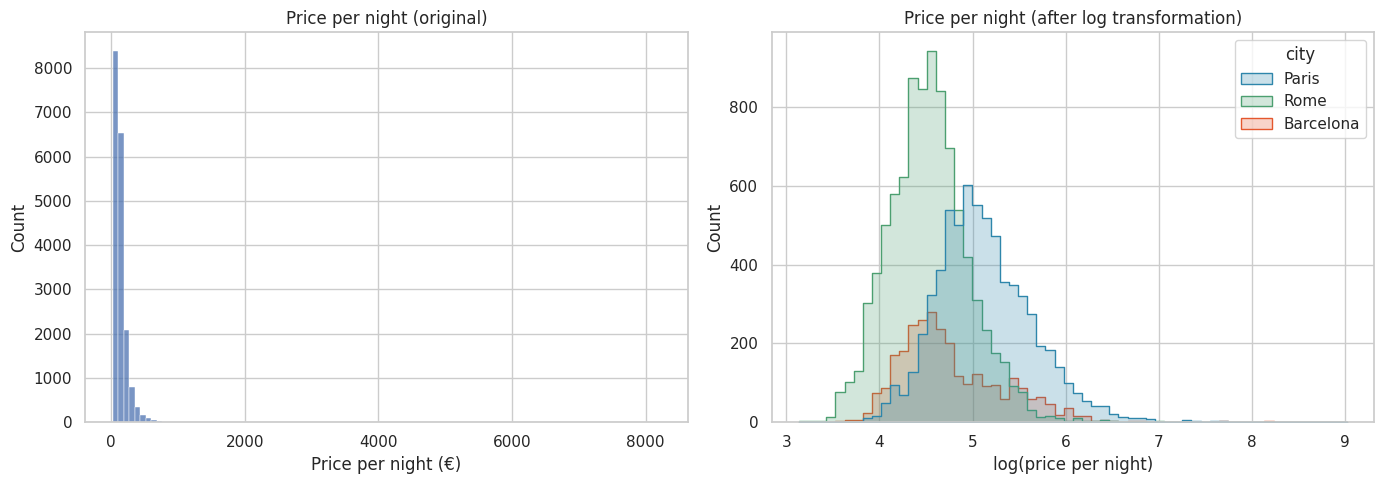

Skewness before log: 18.04
Skewness after log:  0.68


In [26]:
airbnb["log_price"] = np.log(airbnb["price_per_night"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=airbnb, x="price_per_night", bins=100, ax=axes[0])
axes[0].set_title("Price per night (original)")
axes[0].set_xlabel("Price per night (€)")

sns.histplot(data=airbnb, x="log_price", hue="city", palette=CITY_COLOURS,
             bins=60, element="step", ax=axes[1])
axes[1].set_title("Price per night (after log transformation)")
axes[1].set_xlabel("log(price per night)")

plt.tight_layout()
plt.show()

print("Skewness before log:", round(airbnb["price_per_night"].skew(), 2))
print("Skewness after log: ", round(airbnb["log_price"].skew(), 2))

**Observations:**

**Left chart (original prices):**
- Almost all the bars are squeezed into the far left corner, and the chart is almost unreadable. **95% of listings cost €325 a night or less**, but the x-axis stretches all the way to **€8,223** because of a single extreme listing (the Paris listing costing €16,445 for 2 nights, found in Section 2.5).
- This shape is called **right-skewed**: most values are low, with a long thin "tail" of a few very expensive listings stretching to the right.
- **Skewness = 18.04**, which is extremely high (anything above 1 is already considered strongly skewed).

**Right chart (after log):**
- The shape is now close to a **bell curve**, and the skewness drops to **0.68**. We can finally see how prices are really spread.
- **The three cities separate clearly:** Rome sits furthest left (cheapest), Paris furthest right (most expensive), and Barcelona in between.
- **Barcelona has two humps**, one around 4.5 (about €90 a night) and another around 5.5 (about €250 a night). This suggests Barcelona has two different kinds of listings at two different price levels. We check whether this is caused by room type in Section 8.

**Why the log transformation matters:**
- It lets us **see** the real shape of the data, which the original chart hides.
- Many statistical methods and models work better when data is roughly symmetric, so if someone later builds a model to predict price, they would use `log_price`. This is done in **preprocessing, before training a model**, just like the log of GNI per capita in the Happiness × HDI lab.
- We **keep both** columns: `price_per_night` for explaining results in euros, and `log_price` for charts and calculations.

### **6.2 Mean vs median and skewness of every numeric column**

**Q6.2 For every numeric column, how do the mean and median compare, and what does the gap tell us?**

- **Mean** = the average (add everything up, divide by the count). Extreme values pull it towards them.
- **Median** = the middle value when everything is sorted. Extreme values don't affect it.
- **Skewness** measures how lopsided the distribution is:
  - **About 0:** symmetric
  - **Positive:** long tail to the **right** (a few very **high** values). The mean is **above** the median.
  - **Negative:** long tail to the **left** (a few very **low** values). The mean is **below** the median.
  - Above 1 or below -1 is considered **strongly** skewed.

In [27]:
numeric_cols = ["price_per_night", "dist", "metro_dist", "attr_index", "rest_index",
                "cleanliness_rating", "guest_satisfaction_overall", "person_capacity", "bedrooms"]

numeric_summary = pd.DataFrame({
    "mean": airbnb[numeric_cols].mean(),
    "median": airbnb[numeric_cols].median(),
    "skewness": airbnb[numeric_cols].skew()
}).round(2)

numeric_summary

,mean,median,skewness
price_per_night,143.18,112.76,18.04
dist,2.88,2.72,0.59
metro_dist,0.55,0.34,1.98
attr_index,434.32,369.36,2.98
rest_index,990.18,859.31,1.41
cleanliness_rating,9.39,10.00,-2.71
guest_satisfaction_overall,92.42,94.00,-3.02
person_capacity,3.10,3.00,0.83
bedrooms,1.13,1.00,0.96


**Observations:**

- **`price_per_night` (mean €143, median €113, skewness 18.04):** the mean is about 27% higher than the median. A typical traveller pays around **€113 a night**, but the "average" suggests €143 because a small number of very expensive listings pull it up. **For prices, the median is the fairer "typical" value.**
- **`dist` (mean 2.88 km, median 2.72 km, skewness 0.59):** nearly symmetric. Listings are spread fairly evenly across different distances from the centre rather than bunched in one spot.
- **`metro_dist` (mean 0.55 km, median 0.34 km, skewness 1.98):** strongly right-skewed. **Half of all listings are within 340 m of a metro station**, and only a few are far from one. Good metro access is normal in these three cities.
- **`attr_index` (skewness 2.98) and `rest_index` (skewness 1.41):** right-skewed. Most listings are in "normal" areas, and a small number sit in extremely attraction- and restaurant-packed spots.
- **Ratings (skewness -2.71 and -3.02):** these are the only **negatively** skewed columns. The median cleanliness rating is a perfect **10**, and the mean is lower (9.39) because of a small tail of low ratings. This is the **rating inflation** we predicted in Section 1 (PA2).
- **`person_capacity` (median 3) and `bedrooms` (median 1):** slightly right-skewed. Most listings are small, with a few large ones for 5 to 6 guests.

**Q6.3 How are prices spread within each city?**

The same mean vs median comparison, but separately for each city. `groupby("city")` splits the table by city, and `.agg(["mean", "median"])` calculates both for each city. The **gap %** shows how much higher the mean is than the median.

In [28]:
price_by_city = airbnb.groupby("city")["price_per_night"].agg(["mean", "median"]).round(1)
price_by_city["gap_%"] = ((price_by_city["mean"] - price_by_city["median"])
                          / price_by_city["median"] * 100).round(1)
price_by_city

,mean,median,gap_%
city,,,
Barcelona,146.9,104.1,41.1
Paris,196.3,158.8,23.6
Rome,102.7,91.3,12.5


**Observations:**

| City | Mean | Median | Gap |
|---|---|---|---|
| Barcelona | €146.9 | €104.1 | 41.1% |
| Paris | €196.3 | €158.8 | 23.6% |
| Rome | €102.7 | €91.3 | 12.5% |

- **Paris is the most expensive by both measures**, and Rome the cheapest.
- **Barcelona has the biggest gap (41%).** Its typical listing (median) costs only a little more than Rome's, but its mean is pulled up a lot. This matches the two humps in 6.1: Barcelona has a group of much more expensive listings, plus the two extreme €6,943 listings from Section 2.5.
- **Rome has the smallest gap (12.5%)**, so its prices are the most evenly spread, with fewer extreme listings.
- This shows why we compare cities using the **median**: comparing means would make Barcelona look much closer to Paris than a typical traveller would experience.

### **6.3 Guest ratings**

**Q6.4 Do the ratings show the "rating inflation" we predicted in Section 1 (PA2)?**

- **Left:** `countplot` counts how many listings have each cleanliness score (out of 10). It is used for columns with only a few possible values.
- **Right:** a histogram of overall satisfaction (out of 100), since it has many more possible values.

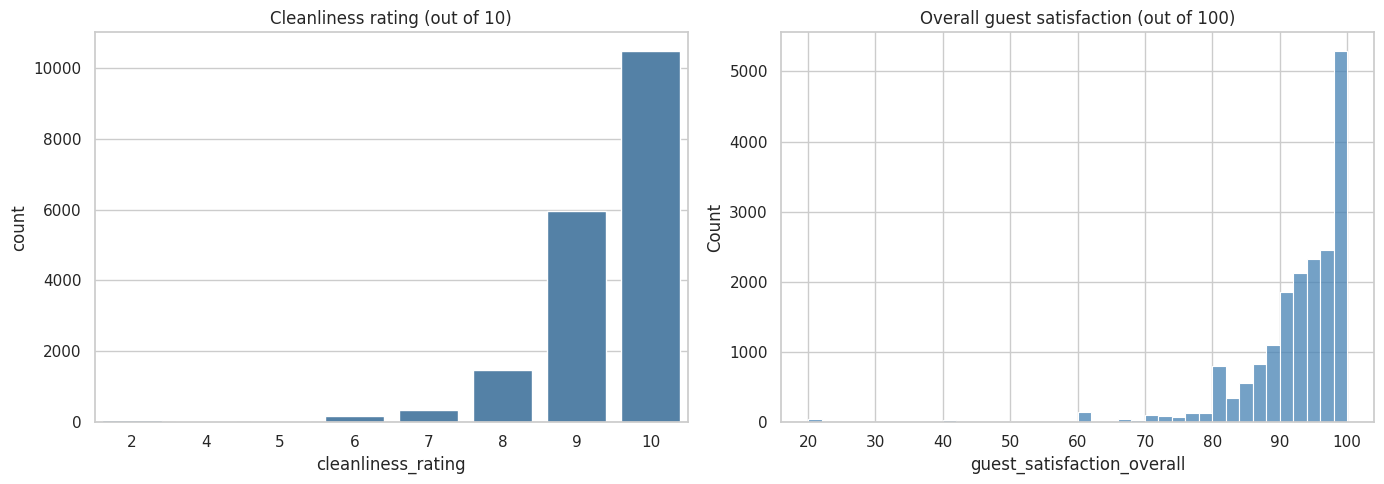

Share of listings with cleanliness 9 or 10: 88.7 %
Share of listings with satisfaction 90 or more: 75.8 %


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=airbnb, x="cleanliness_rating", color="steelblue", ax=axes[0])
axes[0].set_title("Cleanliness rating (out of 10)")

sns.histplot(data=airbnb, x="guest_satisfaction_overall", bins=40, color="steelblue", ax=axes[1])
axes[1].set_title("Overall guest satisfaction (out of 100)")

plt.tight_layout()
plt.show()

print("Share of listings with cleanliness 9 or 10:", round((airbnb["cleanliness_rating"] >= 9).mean() * 100, 1), "%")
print("Share of listings with satisfaction 90 or more:", round((airbnb["guest_satisfaction_overall"] >= 90).mean() * 100, 1), "%")

**Observations:**
- **Rating inflation is confirmed.** **88.7%** of listings have a cleanliness rating of 9 or 10 (56.5% have a perfect 10), and **75.8%** have an overall satisfaction of 90 or more.
- Both charts are **left-skewed**: a huge pile at the top and a thin tail of low scores.
- The small spikes at **20, 40 and 60** in the right chart are the 1, 2 and 3 star scores we explained in Section 3.6.
- **What this means:** on Airbnb, a cleanliness score of **8/10 is actually poor**. Only about 11% of listings score 8 or lower, even though 8 sounds good.
- **Problem for later analysis:** since almost everyone scores 9 or 10, there is very little variation in ratings. So ratings may **not** show strong relationships with price in Section 9, not because ratings don't matter, but because nearly everyone has the same rating.

### **6.4 Categorical columns**

**Q6.5 How many listings fall into each room type, host type and Superhost group? Are the groups balanced?**

`countplot` draws one bar per category. `order=` fixes the order of the bars so they appear in a logical order rather than a random one.

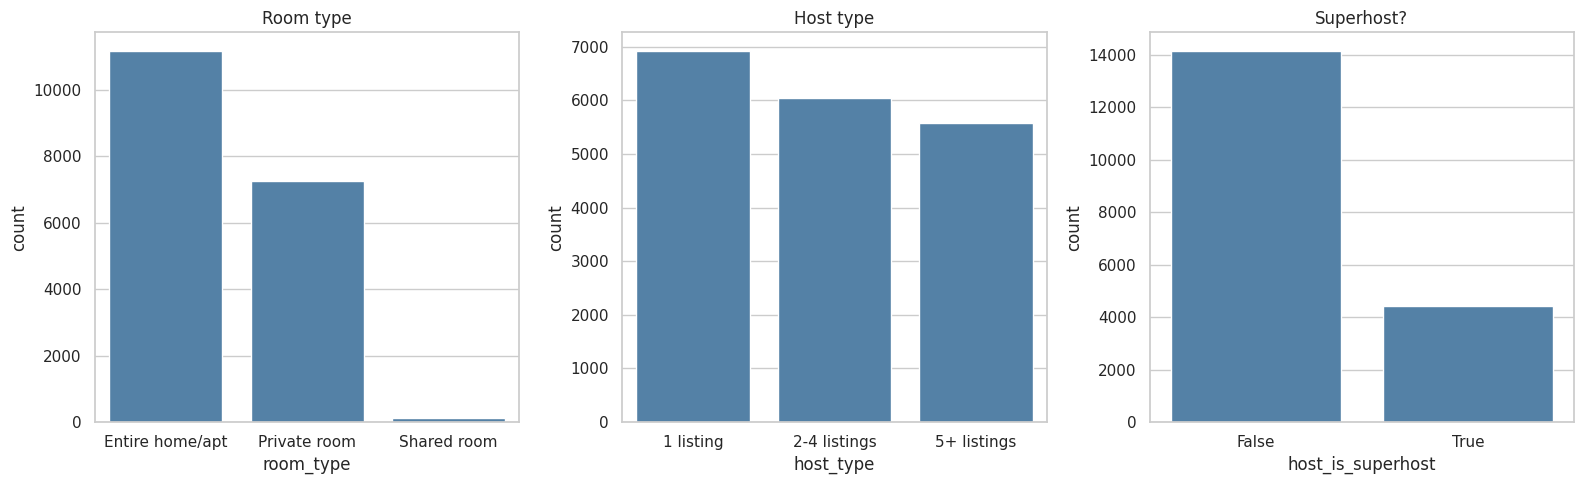

room_type
Entire home/apt    60.2
Private room       39.1
Shared room         0.6
Name: proportion, dtype: float64
host_is_superhost
False    76.3
True     23.7
Name: proportion, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.countplot(data=airbnb, x="room_type", order=["Entire home/apt", "Private room", "Shared room"],
              color="steelblue", ax=axes[0])
axes[0].set_title("Room type")

sns.countplot(data=airbnb, x="host_type", order=["1 listing", "2-4 listings", "5+ listings"],
              color="steelblue", ax=axes[1])
axes[1].set_title("Host type")

sns.countplot(data=airbnb, x="host_is_superhost", color="steelblue", ax=axes[2])
axes[2].set_title("Superhost?")

plt.tight_layout()
plt.show()

print(airbnb["room_type"].value_counts(normalize=True).round(3) * 100)
print(airbnb["host_is_superhost"].value_counts(normalize=True).round(3) * 100)

**Observations:**

**Room type:**
- Entire home/apt: **11,170 (60.2%)**, Private room: **7,260 (39.1%)**, Shared room: only **118 (0.6%)**.
- **Shared rooms are so rare** that any average we calculate for them is unreliable. When we compare room types in Section 8, we mainly compare **entire homes vs private rooms** and mention shared rooms only briefly.

**Host type:**
- 1 listing: **6,923 (37.3%)**, 2-4 listings: **6,043 (32.6%)**, 5+ listings: **5,582 (30.1%)**.
- These groups are **well balanced**, so comparing them is fair.

**Superhost:**
- Only **23.7%** of listings are run by Superhosts, and **76.3%** are not. The groups are **imbalanced**.
- Comparing them is still fine, since even the smaller group has over 4,000 listings. But, as in the Happiness × HDI lab (D5): if someone built a model to predict "is this a Superhost?", a lazy model that always answers "No" would already be **76% accurate** while being useless. So **accuracy would be a misleading metric** for that kind of model.

### **6.5 Summary of Univariate Analysis**

1. **Price is extremely right-skewed** (skewness 18). A log transformation makes it close to a bell curve, so we use `log_price` for charts and the **median** for typical prices.
2. **Paris is the most expensive and Rome the cheapest.** Barcelona's prices are split into two groups, which we investigate in Section 8.
3. **Ratings are inflated:** almost 9 in 10 listings score 9 or 10 for cleanliness, so ratings have little variation to work with.
4. **Shared rooms are too rare (0.6%)** to compare reliably, and Superhosts are a minority (24%).
5. Most listings are **small** (median 3 guests, 1 bedroom) and **close to a metro** (median 340 m).

We added one new column, `log_price`, so the table now has **18,548 rows and 23 columns**.

---
## **7. Outlier Investigation**

An **outlier** is a value that is very different from the rest. In Sections 2 and 6 we already saw a few extremely expensive listings. In this section we:
1. Find outliers **statistically**, using the IQR method.
2. Check them with **real-world (domain) reasoning**: does the price make sense for what the listing offers?
3. Make a clear decision for each: **keep**, **flag** or **remove**.

As in the Happiness × HDI lab, a **statistical outlier** is not automatically a **mistake**. A big 6-bedroom apartment should cost much more than a studio.

### **7.1 Box plots of price per city**

**Q7.1 What do the price outliers look like in each city?**

**How to read a box plot:**
- The **box** covers the middle 50% of listings (from Q1, the 25th percentile, to Q3, the 75th percentile).
- The **line inside the box** is the **median**.
- The **whiskers** reach out to the furthest values that are still considered "normal".
- The **dots** beyond the whiskers are **outliers**.

We draw it twice: once on the normal scale and once on a **log scale** (`set_yscale("log")`), for the same reason we used a log transformation in Section 6.1.

`hue="city"` with `legend=False` gives each box its city colour without adding an unnecessary legend.

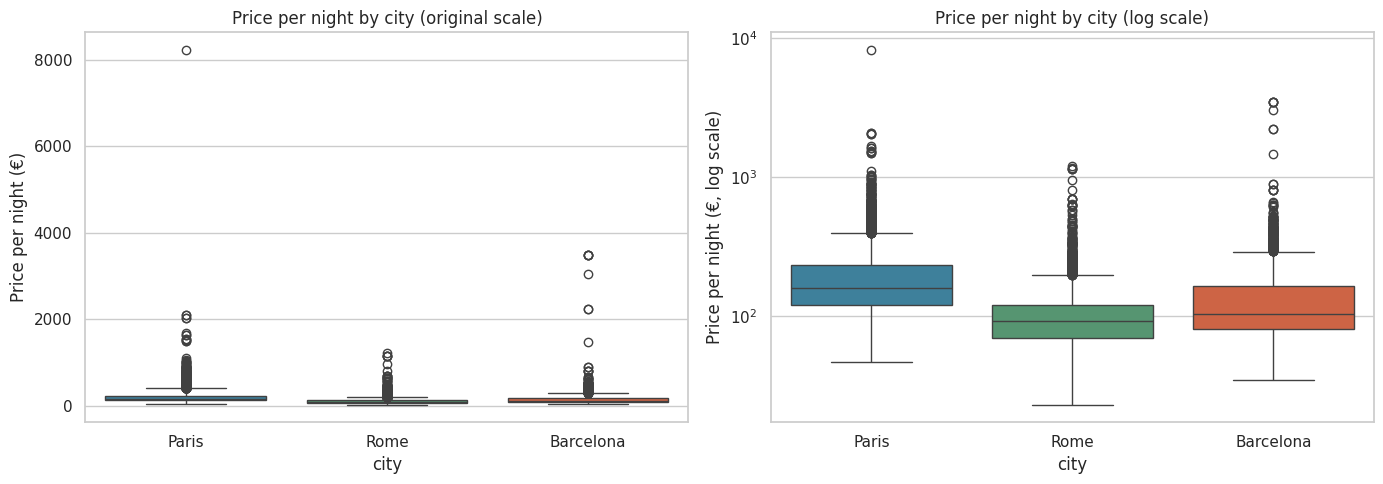

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=airbnb, x="city", y="price_per_night", hue="city",
            palette=CITY_COLOURS, legend=False, ax=axes[0])
axes[0].set_title("Price per night by city (original scale)")
axes[0].set_ylabel("Price per night (€)")

sns.boxplot(data=airbnb, x="city", y="price_per_night", hue="city",
            palette=CITY_COLOURS, legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price per night by city (log scale)")
axes[1].set_ylabel("Price per night (€, log scale)")

plt.tight_layout()
plt.show()

**Observations:**
- **Left (original scale):** the boxes are squashed flat at the bottom because one Paris listing at about €8,223 a night stretches the whole axis. This chart is not readable, which again shows why we need the log scale.
- **Right (log scale):** now we can see the boxes clearly. **Paris's box is the highest**, Rome's the lowest, and Barcelona's is in between but **taller**, meaning its prices are more spread out (matching its two price groups from Section 6.1).
- **All three cities have many dots above the top whisker**, so outliers exist everywhere. There are no dots below the bottom whisker, so there are **no unusually cheap listings**, only unusually expensive ones.

### **7.2 The IQR method, calculated per city**

**Q7.2 How many listings are statistical outliers in each city?**

**The IQR method:**
- **Q1** = the price that 25% of listings are below. **Q3** = the price that 75% of listings are below.
- **IQR** (Interquartile Range) = Q3 minus Q1, which is the spread of the middle 50%.
- **Upper fence** = Q3 + 1.5 × IQR. Anything **above** it is a high outlier.
- **Lower fence** = Q1 minus 1.5 × IQR. Anything **below** it is a low outlier.

**Why per city?** Each city has its own normal price level. A €350 night is expensive in Rome but normal in Paris. So each city gets its **own** fences, calculated from its own listings.

**How the code works:** `groupby("city")` gives us one city's listings at a time (`group`). `.quantile(0.25)` and `.quantile(0.75)` calculate Q1 and Q3. We collect the results in a list and turn it into a table.

In [32]:
iqr_rows = []
for city, group in airbnb.groupby("city"):
    q1 = group["price_per_night"].quantile(0.25)
    q3 = group["price_per_night"].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    lower = q1 - 1.5 * iqr
    iqr_rows.append({
        "city": city,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower,
        "upper_fence": upper,
        "high_outliers": (group["price_per_night"] > upper).sum(),
        "low_outliers": (group["price_per_night"] < lower).sum(),
        "total_listings": len(group)
    })

iqr_table = pd.DataFrame(iqr_rows).round(1)
iqr_table

,city,Q1,Q3,IQR,lower_fence,upper_fence,high_outliers,low_outliers,total_listings
0,Barcelona,80.4,164.9,84.5,-46.3,291.6,227,0,2833
1,Paris,120.5,231.0,110.6,-45.4,396.9,386,0,6688
2,Rome,69.2,120.4,51.2,-7.6,197.2,433,0,9027


**Observations:**

| City | Q1 | Q3 | Upper fence | High outliers | Share |
|---|---|---|---|---|---|
| Barcelona | €80.4 | €164.9 | €291.6 | 227 | 8.0% |
| Paris | €120.5 | €231.0 | €396.9 | 386 | 5.8% |
| Rome | €69.2 | €120.4 | €197.2 | 433 | 4.8% |

- In total, **1,046 listings (5.6%)** are statistical outliers.
- **Every lower fence is negative**, and a price can't be below €0, so **there are no low outliers**. Only the expensive side has outliers, which matches the right-skew from Section 6.
- **Barcelona has the highest share of outliers (8%)**, consistent with its spread-out prices.
- Each city's fence is very different: a listing is an outlier in Rome above about €197 a night, but in Paris only above about €397.

**Q7.3 What would happen if we used one IQR for all three cities combined?**

We calculate a single upper fence from all 18,548 listings and count how many listings from each city fall above it.

In [33]:
q1_all = airbnb["price_per_night"].quantile(0.25)
q3_all = airbnb["price_per_night"].quantile(0.75)
one_fence = q3_all + 1.5 * (q3_all - q1_all)

print("One upper fence for all cities:", round(one_fence, 1))
print(airbnb[airbnb["price_per_night"] > one_fence]["city"].value_counts())

One upper fence for all cities: 293.0
city
Paris        909
Barcelona    226
Rome          78
Name: count, dtype: int64


**Observation:** A single fence of about **€293** would flag **909 Paris listings** as outliers but only **78 in Rome**. Most of those Paris listings are just **normal Paris prices**; they only look "extreme" because the cheaper Rome listings pull the combined fence down.

This shows that the IQR method only makes sense **within a fair comparison group**. Mixing cities with different price levels would give misleading results, the same problem as Rome dominating combined averages (Section 2.2).

### **7.3 Who are the outliers?**

**Q7.4 Are the statistical outliers mistakes, or real listings that are simply bigger or better located?**

First we add a **flag column** `price_outlier`: True if the listing is above its city's upper fence. `.map(upper_fences)` looks up the correct fence for each row's city.

Then we compare the outliers with all other listings on size and location.

In [34]:
upper_fences = iqr_table.set_index("city")["upper_fence"]
airbnb["price_outlier"] = airbnb["price_per_night"] > airbnb["city"].map(upper_fences)

outliers = airbnb[airbnb["price_outlier"]]
normal = airbnb[~airbnb["price_outlier"]]

comparison = pd.DataFrame({
    "Outliers": [
        (outliers["room_type"] == "Entire home/apt").mean() * 100,
        outliers["person_capacity"].mean(),
        outliers["bedrooms"].mean(),
        outliers["dist"].median()
    ],
    "Normal listings": [
        (normal["room_type"] == "Entire home/apt").mean() * 100,
        normal["person_capacity"].mean(),
        normal["bedrooms"].mean(),
        normal["dist"].median()
    ]
}, index=["% entire homes", "average guests", "average bedrooms", "median distance from centre (km)"]).round(2)

comparison

,Outliers,Normal listings
% entire homes,91.20,58.37
average guests,4.68,3.00
average bedrooms,1.89,1.08
median distance from centre (km),2.11,2.78


**Observations:**

| | Outliers | Normal listings |
|---|---|---|
| % entire homes | 91.2% | 58.4% |
| Average guests | 4.68 | 3.00 |
| Average bedrooms | 1.89 | 1.08 |
| Median distance from centre | 2.11 km | 2.78 km |

- The outliers are mostly **entire homes**, **bigger** (more guests and bedrooms) and **closer to the centre**. All of these are good real-world reasons for a higher price.
- So most statistical outliers are **real, expensive listings**, not errors. They are **statistical outliers but not domain outliers**.
- `~` means "not", so `~airbnb["price_outlier"]` selects the normal listings.

### **7.4 The most extreme listings: a domain check**

**Q7.5 Do the 10 most expensive listings make sense for what they offer?**

In [35]:
cols = ["city", "day_type", "price_per_night", "room_type", "person_capacity",
        "bedrooms", "dist", "guest_satisfaction_overall", "host_type"]

airbnb.sort_values("price_per_night", ascending=False)[cols].head(10).round(1)

,city,day_type,price_per_night,room_type,person_capacity,bedrooms,dist,guest_satisfaction_overall,host_type
2348,Paris,Weekdays,8222.8,Entire home/apt,2,1,4.6,100,1 listing
16779,Barcelona,Weekdays,3471.9,Entire home/apt,2,1,4.5,84,5+ listings
16780,Barcelona,Weekdays,3471.9,Entire home/apt,2,1,4.6,87,5+ listings
18169,Barcelona,Weekends,3471.4,Entire home/apt,2,1,4.6,87,5+ listings
18168,Barcelona,Weekends,3471.4,Entire home/apt,2,1,4.5,84,5+ listings
17764,Barcelona,Weekends,3043.1,Entire home/apt,2,3,1.7,100,5+ listings
18389,Barcelona,Weekends,2233.6,Entire home/apt,6,6,5.8,90,5+ listings
17063,Barcelona,Weekdays,2233.6,Entire home/apt,6,6,5.8,90,5+ listings
6637,Paris,Weekends,2094.2,Entire home/apt,4,3,3.9,90,1 listing
3086,Paris,Weekdays,2092.3,Entire home/apt,4,3,3.9,90,1 listing


**Observations:**

**Suspicious (price doesn't make sense for the listing):**
1. **Paris, about €8,223 a night:** a **1-bedroom apartment for 2 guests**, 4.6 km from the centre. The typical Paris entire home costs about €171 a night, so this is about **48 times** more, with nothing special about the listing to explain it.
2. **Barcelona, about €3,472 a night, 4 rows:** these are **two different 1-bedroom, 2-guest apartments** (slightly different locations and ratings, 84 and 87), each appearing in **both** the weekday and weekend files at exactly the same price. Both belong to a business host (5+ listings). This is about **14 times** the typical Barcelona entire home.

A likely explanation: hosts sometimes set an extremely high price on dates they don't want booked, as a way of blocking them. We can't prove this, but these prices clearly don't reflect what the apartments are worth.

**Believable (expensive, but the listing explains it):**
- **Barcelona, about €2,234 a night:** **6 bedrooms for 6 guests**. A large luxury property.
- **Paris, about €2,093 a night:** **3 bedrooms for 4 guests**, rated 90. A large, high-end apartment.
- **Barcelona, about €3,043 a night:** 3 bedrooms and a perfect 100 rating. Very expensive, but a large, top-rated property, so we give it the benefit of the doubt.

### **7.5 Decisions**

**Q7.6 For each type of outlier, do we keep it, flag it, or remove it?**

| Outliers | Type | Decision | Reason |
|---|---|---|---|
| 1,046 IQR outliers (per city) | Statistical, but real | **Keep and flag** (`price_outlier`) | Mostly large, central entire homes. Their high prices make sense, and removing them would hide real luxury listings. |
| Large expensive listings (6 bedrooms, 3 bedrooms) | Statistical, but believable | **Keep** | The price matches the size and quality. |
| 5 rows: 1-bedroom, 2-guest flats above €3,000 a night | Statistical **and** domain (suspicious) | **Remove** | The price is 14 to 48 times the city's typical entire home, with nothing about the listing to explain it. Likely placeholder prices, not real market prices. |

The rule for removal is simple and clear: **price above €3,000 a night AND 1 bedroom or fewer**. It catches exactly those 5 rows and nothing else.

In [36]:
suspicious = (airbnb["price_per_night"] > 3000) & (airbnb["bedrooms"] <= 1)
print("Rows being removed:")
print(airbnb.loc[suspicious, cols].round(1))

airbnb = airbnb[~suspicious].reset_index(drop=True)
print("\nShape after removing suspicious rows:", airbnb.shape)

Rows being removed:
            city  day_type  price_per_night        room_type  person_capacity  \
2348       Paris  Weekdays           8222.8  Entire home/apt                2   
16779  Barcelona  Weekdays           3471.9  Entire home/apt                2   
16780  Barcelona  Weekdays           3471.9  Entire home/apt                2   
18168  Barcelona  Weekends           3471.4  Entire home/apt                2   
18169  Barcelona  Weekends           3471.4  Entire home/apt                2   

       bedrooms  dist  guest_satisfaction_overall    host_type  
2348          1   4.6                         100    1 listing  
16779         1   4.5                          84  5+ listings  
16780         1   4.6                          87  5+ listings  
18168         1   4.5                          84  5+ listings  
18169         1   4.6                          87  5+ listings  

Shape after removing suspicious rows: (18543, 24)


**Answer:** 5 rows removed (1 in Paris, 4 in Barcelona). The table now has **18,543 rows and 24 columns** (we added `price_outlier` in 7.3). `reset_index(drop=True)` renumbers the rows from 0 after the removal.

**Statistical vs domain outliers, the key lesson:**
- The IQR method flagged **1,046 listings**, and most of them are **real**.
- The truly suspicious listings were only **5 rows**, and we found them by **thinking about what each listing offers**, not by the formula.
- The IQR method only tells us a value is **unusual**. It can't tell us whether it's **wrong**. That needs domain knowledge.

---
## **8. Comparing the Cities: The 4 Components**

This is the main part of our analysis. We compare Paris, Rome and Barcelona on the 4 components from Section 0.1:

| Component | Questions |
|---|---|
| **8.1 Price** | Which city is most expensive? Do weekends cost more? |
| **8.2 Location** | Does distance from the centre, metro, attractions and restaurants affect price? |
| **8.3 Room type & size** | What kind of accommodation does each city offer, and how does it change the price? |
| **8.4 Hosts & satisfaction** | Do Superhosts charge more? Does cleanliness drive satisfaction? |

**Rules we follow in this section:**
- We compare cities using the **median** price, because prices are strongly right-skewed (Section 6.2).
- Each city keeps its fixed colour from Section 0.7.
- Cities are always shown in the same order, from most to least expensive: **Paris, Barcelona, Rome**.

In [37]:
city_order = ["Paris", "Barcelona", "Rome"]
DAY_COLOURS = {"Weekdays": "#9DB4C0", "Weekends": "#E07A5F"}

**How the code works:** `city_order` fixes the order of the cities in every chart. `DAY_COLOURS` gives weekdays and weekends their own fixed colours, the same idea as `CITY_COLOURS`.

### **8.1 Component 1: Price**

**Q8.1 Which city is the most expensive?**

We calculate the median, mean and number of listings for each city, then show the medians in a bar chart.

**How the code works:**
- `.agg(["median", "mean", "count"])` calculates all three for each city at once.
- In the bar chart, `estimator="median"` makes each bar show the **median** (by default seaborn shows the mean). `errorbar=None` removes the small error lines on top of the bars to keep the chart clean.
- The `for` loop writes the value on top of each bar. `ax.patches` is the list of bars in the chart, and `ax.annotate` places text at a chosen position, here the centre-top of each bar.

           median   mean  count
city                           
Paris       158.8  195.1   6687
Barcelona   104.1  142.2   2829
Rome         91.3  102.7   9027


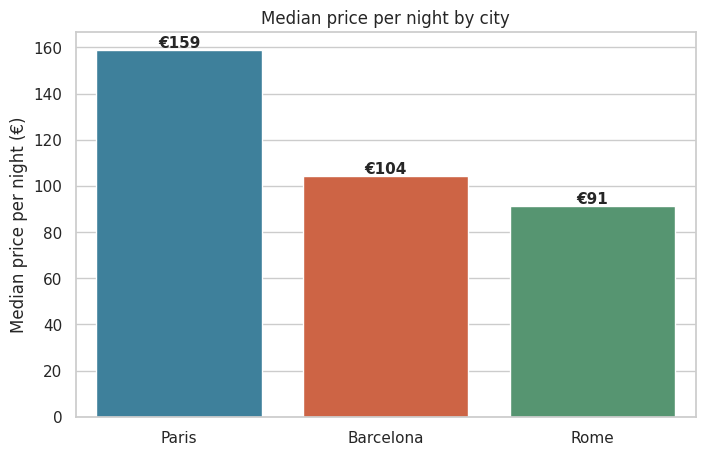

In [38]:
city_prices = airbnb.groupby("city")["price_per_night"].agg(["median", "mean", "count"]).round(1)
city_prices = city_prices.sort_values("median", ascending=False)
print(city_prices)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=airbnb, x="city", y="price_per_night", hue="city", order=city_order,
                 palette=CITY_COLOURS, estimator="median", errorbar=None, legend=False)

for bar in ax.patches:
    ax.annotate(f"€{bar.get_height():.0f}",
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.title("Median price per night by city")
plt.ylabel("Median price per night (€)")
plt.xlabel("")
plt.show()

**Observations:**

| City | Median per night | Mean per night | Listings | Middle 50% of prices |
|---|---|---|---|---|
| Paris | €158.8 | €195.1 | 6,687 | €120 to €231 |
| Barcelona | €104.1 | €142.2 | 2,829 | €80 to €165 |
| Rome | €91.3 | €102.7 | 9,027 | €69 to €120 |

- **Paris is clearly the most expensive city.** A typical Paris listing costs about **53% more than in Barcelona** and **74% more than in Rome**.
- **Barcelona and Rome are much closer**: Barcelona's median is only about 14% higher than Rome's.
- **Hypothesis H4 ("Paris will be the most expensive") is confirmed.**
- The mean is higher than the median in every city, again showing the right-skew. In Barcelona the gap is the largest (€142 vs €104), because of its group of expensive entire homes (Section 6.1).
- *(The "middle 50%" column comes from the Q1 and Q3 values in Section 7.2.)*

**Q8.2 Do weekend stays cost more than weekday stays in each city?**

We calculate the median weekday and weekend price for each city and the **percentage change** from weekdays to weekends.

**How the code works:**
- `groupby(["city", "day_type"])` groups by both city and day type, giving 6 groups.
- `.unstack()` turns the day types into two side-by-side columns (Weekdays, Weekends), which makes the table easier to read.
- `% change = (weekend minus weekday) ÷ weekday × 100`. A positive value means weekends cost more.
- In the chart, `hue="day_type"` puts weekday and weekend bars next to each other for each city.

day_type   Weekdays  Weekends  weekend_change_%
city                                           
Barcelona     104.3     101.8              -2.4
Paris         159.3     158.1              -0.8
Rome           89.9      92.2               2.6


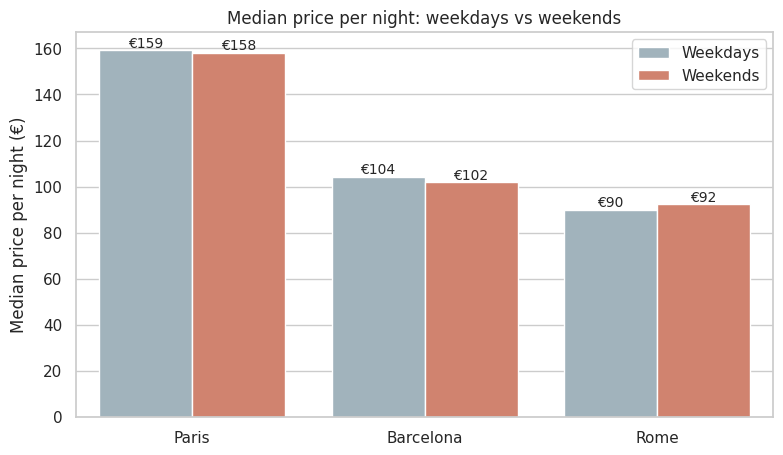

In [39]:
day_prices = airbnb.groupby(["city", "day_type"])["price_per_night"].median().unstack().round(1)
day_prices["weekend_change_%"] = ((day_prices["Weekends"] - day_prices["Weekdays"])
                                  / day_prices["Weekdays"] * 100).round(1)
print(day_prices)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=airbnb, x="city", y="price_per_night", hue="day_type", order=city_order,
                 palette=DAY_COLOURS, estimator="median", errorbar=None)

for bar in ax.patches:
    if bar.get_height() > 0:
        ax.annotate(f"€{bar.get_height():.0f}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.title("Median price per night: weekdays vs weekends")
plt.ylabel("Median price per night (€)")
plt.xlabel("")
plt.legend(title="")
plt.show()

**Observations:**

| City | Weekdays | Weekends | Change |
|---|---|---|---|
| Paris | €159.3 | €158.1 | **-0.8%** |
| Barcelona | €104.3 | €101.8 | **-2.4%** |
| Rome | €89.9 | €92.2 | **+2.6%** |

- **The differences are tiny.** In every city, weekday and weekend prices are within about 3% of each other.
- In **Paris and Barcelona**, the median weekend price is actually slightly **lower**. Only **Rome** is slightly more expensive at weekends.
- **So, at first look, Hypothesis H1 ("weekends will cost more in all three cities") is NOT confirmed.** This surprised us.

**Mean vs median can give different answers here.** Using the **mean**, Barcelona's weekends look about 3.6% **more** expensive (€139.9 vs €144.9), but using the **median** they look 2.4% **cheaper**. When the difference is this small, the choice of measure can flip the conclusion. This is why we don't trust a chart alone, and why we test this properly in **Section 10**.

**Is this the full story?** Not yet. In **Section 9** we look at weekday and weekend prices **within each room type**, and Barcelona gives a surprising result.

### **8.2 Component 2: Location**

**Q8.3 Does price go down as you move away from the city centre, in all three cities?**

We use the distance bands from Section 5.3 and plot the **median price in each band** for each city. A `pointplot` draws one dot per band and connects the dots with lines, which makes it easy to see whether price goes up or down as distance increases.

`observed=True` in `groupby` tells pandas to only show band combinations that actually exist in the data (needed because `dist_band` is a category column).

dist_band  Under 1 km  1-3 km  3-5 km  Over 5 km
city                                            
Paris           221.8   166.6   139.2      168.0
Barcelona       114.6   109.9    87.3       66.4
Rome             83.2   107.0    86.4       72.7


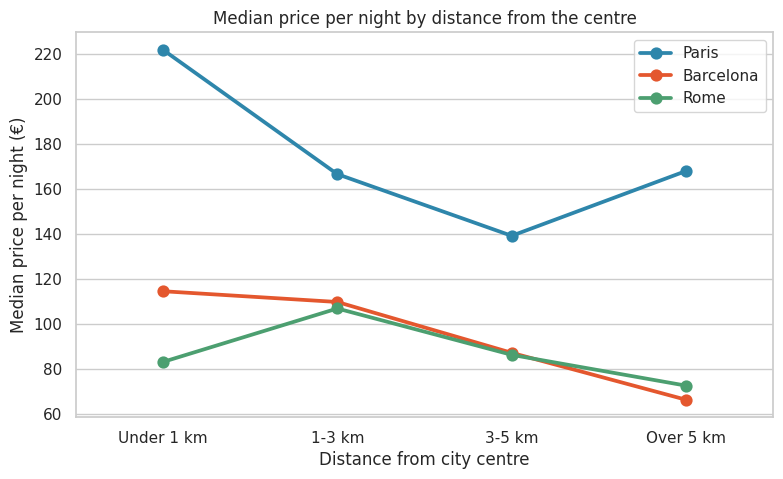

In [40]:
band_prices = airbnb.groupby(["city", "dist_band"], observed=True)["price_per_night"].median().unstack().round(1)
print(band_prices.loc[city_order])

plt.figure(figsize=(9, 5))
sns.pointplot(data=airbnb, x="dist_band", y="price_per_night", hue="city", hue_order=city_order,
              palette=CITY_COLOURS, estimator="median", errorbar=None)
plt.title("Median price per night by distance from the centre")
plt.xlabel("Distance from city centre")
plt.ylabel("Median price per night (€)")
plt.legend(title="")
plt.show()

**Observations:**

| City | Under 1 km | 1-3 km | 3-5 km | Over 5 km |
|---|---|---|---|---|
| Paris | €221.8 | €166.6 | €139.2 | €168.0 |
| Barcelona | €114.6 | €109.9 | €87.3 | €66.4 |
| Rome | €83.2 | €107.0 | €86.4 | €72.7 |

- **Barcelona** behaves exactly as expected: price falls steadily with every band, from €115 in the centre to €66 in the outer city. (The "Over 5 km" group has only 87 listings, so that last value is less reliable, as noted in Section 5.3.)
- **Paris** falls from €222 in the centre to €139 at 3 to 5 km, then **rises again** to €168 beyond 5 km. Our data doesn't tell us why. We only note that this outer group is mostly entire homes (81%).
- **Rome is the surprise:** listings **under 1 km are cheaper** (€83) than those 1 to 3 km away (€107). When we checked, **60% of Rome's listings under 1 km are private rooms**, compared with only 32% at 1 to 3 km. Cheaper room types pull that band's median down. It also depends on where the researchers placed Rome's "centre" point: the most attractive areas may lie 1 to 3 km from it.
- **Hypothesis H2 ("price goes down with distance in all three cities") is only partly confirmed:** clearly in Barcelona, mostly in Paris, but not smoothly in Rome.
- **Lesson:** distance to one single "centre" point is a rough measure of location. The next question looks at better ones.

**Q8.4 How strongly is price related to each location measure in each city?**

We use **correlation**, a number from **-1 to +1** that shows how two columns move together:
- **Positive:** when one goes up, the other tends to go up.
- **Negative:** when one goes up, the other tends to go down.
- **Close to 0:** no clear relationship.

A rough guide to strength: below 0.1 = none, 0.1 to 0.3 = weak, 0.3 to 0.5 = moderate, above 0.5 = strong (the same guide applies to negative values).

**Why Spearman and not Pearson?**
- **Pearson** (the default) measures a straight-line relationship using the actual values, so a few extremely expensive listings can distort it a lot.
- **Spearman** first replaces each value with its **rank** (1st, 2nd, 3rd...) and then compares the ranks. It asks: *"do more expensive listings tend to be closer?"* It isn't affected by how extreme the extreme values are.
- Our prices are strongly skewed (Section 6.1), so **Spearman is more reliable here**.

We use the **raw** `attr_index` and `rest_index`, not the normalised ones, because the normalised versions were rescaled separately in each file (Section 2.6), while the raw scores are consistent for the whole city.

In [42]:
location_cols = ["dist", "metro_dist", "attr_index", "rest_index"]

spearman_table = pd.DataFrame(index=location_cols)
for city in city_order:
    city_data = airbnb[airbnb["city"] == city]
    spearman_table[city] = [city_data["price_per_night"].corr(city_data[col], method="spearman")
                            for col in location_cols]

spearman_table.round(3)

,Paris,Barcelona,Rome
dist,-0.234,-0.286,-0.221
metro_dist,-0.045,-0.093,0.102
attr_index,0.458,0.290,0.520
rest_index,0.391,0.292,0.521


**Observations:**

| Location measure | Paris | Barcelona | Rome |
|---|---|---|---|
| `dist` (distance from centre) | -0.234 | -0.286 | -0.221 |
| `metro_dist` (distance to metro) | -0.045 | -0.093 | +0.102 |
| `attr_index` (attractions nearby) | **+0.458** | +0.290 | **+0.520** |
| `rest_index` (restaurants nearby) | +0.391 | +0.292 | **+0.521** |

- **Distance from the centre:** negative in all three cities, so price falls as distance grows, but only **weakly** (about -0.22 to -0.29).
- **Does distance matter more in one city?** Barcelona's is slightly the strongest, but the three values are very close, so **no city stands out**. (With Pearson, Rome looked strongest instead. The ranking changes with the method, which shows we shouldn't over-interpret small differences.)
- **Distance to metro barely matters** (all close to 0). This matches Section 6.2: half of all listings are within 340 m of a metro station, so there is very little difference between listings to explain prices. In Rome it is even slightly positive; one possible reason is that Rome's historic centre has relatively few metro stations.
- **Attractions and restaurants matter most.** In Paris and Rome, `attr_index` has a **moderate to strong** positive correlation with price (0.46 and 0.52), about **twice as strong as distance**. Being near popular places raises prices much more than simply being near the centre point. This agrees with what the researchers found in their paper (Section 0.2).
- **Barcelona has the weakest location effects** overall. Its prices seem to be driven more by **room type** (the two price groups from Section 6.1), which we look at in Component 3.
- **Note for Section 11:** `dist` and `attr_index` are themselves strongly related (listings near the centre are also near attractions). When two predictor columns carry overlapping information, that is **multicollinearity**.

**Q8.5 Where are the most expensive listings on the map?**

**Interactive map:** we use `plotly`, which creates charts you can **zoom, drag and hover over**. Hover over any dot to see its price, room type and rating.

**How the code works:**
- We write a function `show_city_map(city)` so the same code draws a map for each city.
- `px.scatter_map` places each listing on a real map using its `lat` and `lng`.
- `color="price_per_night"` colours each dot by price: **blue = cheap, red = expensive**.
- `range_color` sets the colour scale from the 5th to the 95th percentile of that city's prices, so a few extreme listings don't make every other dot the same colour.
- `hover_data` chooses what appears when you hover over a dot. `False` hides lat and lng from the hover box.
- `map_style="carto-positron"` is a clean, light background map that doesn't need any account or key.

In [43]:
def show_city_map(city):
    city_data = airbnb[airbnb["city"] == city]
    low = city_data["price_per_night"].quantile(0.05)
    high = city_data["price_per_night"].quantile(0.95)

    fig = px.scatter_map(
        city_data, lat="lat", lon="lng", color="price_per_night",
        color_continuous_scale="Turbo", range_color=[low, high],
        opacity=0.6, zoom=11, height=550, map_style="carto-positron",
        hover_data={"price_per_night": ":.0f", "room_type": True,
                    "guest_satisfaction_overall": True, "lat": False, "lng": False},
        title=f"{city}: Airbnb listings coloured by price per night (€)"
    )
    fig.show()

show_city_map("Paris")

In [44]:
show_city_map("Barcelona")

In [50]:
show_city_map("Rome")

To support what we see on the maps with numbers, we compare the **most expensive 10%** of listings in each city with all the other listings.

In [46]:
for city in city_order:
    city_data = airbnb[airbnb["city"] == city]
    cutoff = city_data["price_per_night"].quantile(0.9)
    top = city_data[city_data["price_per_night"] >= cutoff]
    rest = city_data[city_data["price_per_night"] < cutoff]
    print(f"{city}: most expensive 10% median distance = {top['dist'].median():.2f} km, "
          f"other listings = {rest['dist'].median():.2f} km")

Paris: most expensive 10% median distance = 2.13 km, other listings = 3.06 km
Barcelona: most expensive 10% median distance = 1.56 km, other listings = 1.75 km
Rome: most expensive 10% median distance = 2.26 km, other listings = 2.97 km


**Observations:**
- In every city the most expensive 10% of listings sit **closer to the centre**: Paris 2.13 km vs 3.06 km, Rome 2.26 km vs 2.97 km, Barcelona 1.56 km vs 1.75 km.
- Barcelona's gap is the smallest, which again shows that location matters least there.
- **On the maps:**
  - **Rome** shows the clearest pattern: a tight cluster of red and orange (expensive) listings in the historic centre, inside the bend of the river Tiber, with listings becoming bluer (cheaper) the further out they are. Even private rooms in this central cluster can cost over €300 a night. This matches Rome having the strongest link between attractions and price (0.52).
  - **Paris:** almost all listings are inside the city boundary, with very few in the suburbs. Expensive listings are densest in the centre, north of the Seine, and in the west near the river, while cheaper listings are more common towards the north-east and south edges.
  - **Barcelona:** the densest cluster, in the old town near the port, is mostly blue and green (cheap), because most Barcelona listings are private rooms. The red (expensive) listings are scattered across the city rather than grouped in one area, which matches Barcelona having the weakest location effect.
  - **Note:** each map has its own colour scale (from the 5th to the 95th percentile of that city's prices), so red means about €400 a night in Paris but only about €196 in Rome. The colours show what is expensive **for that city** and should not be compared between maps.

### **Summary of Component 2: Location**
1. Price falls with distance from the centre, but **only weakly**, and not smoothly in Rome.
2. **Being near attractions and restaurants matters about twice as much as distance** in Paris and Rome.
3. **Metro distance barely matters**, because almost every listing is close to a metro.
4. **Barcelona's prices depend least on location.** Room type seems to matter more there, which we check next.

### **8.3 Component 3: Room Type & Size**

**Q8.6 What kind of accommodation does each city offer?**

We calculate the **percentage** of each room type in each city and show it as a **stacked bar chart**: one bar per city, split into coloured sections that add up to 100%.

**How the code works:**
- `pd.crosstab(..., normalize="index")` counts the room types in each city and turns the counts into proportions (each row adds up to 1). Multiplying by 100 gives percentages.
- `.loc[city_order, room_order]` puts the rows and columns in our chosen order.
- `.plot(kind="bar", stacked=True)` draws the stacked bars directly from the table.
- `ax.bar_label(...)` writes the percentage inside each section. `ax.containers` holds one group of bar sections per room type.
- `bbox_to_anchor` moves the legend outside the chart so it doesn't cover the bars.

room_type  Entire home/apt  Private room  Shared room
city                                                 
Paris                 75.8          22.8          1.4
Barcelona             19.0          80.6          0.4
Rome                  61.6          38.3          0.1


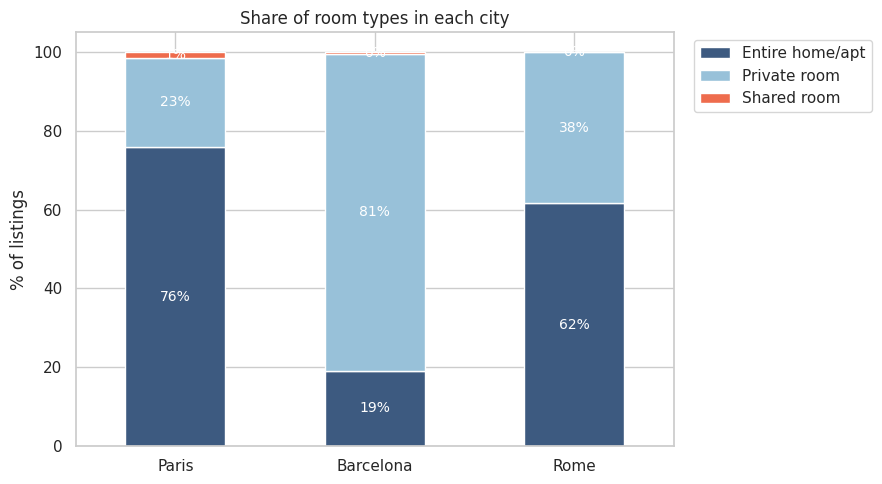

In [47]:
room_order = ["Entire home/apt", "Private room", "Shared room"]
ROOM_COLOURS = {"Entire home/apt": "#3D5A80", "Private room": "#98C1D9", "Shared room": "#EE6C4D"}

room_share = pd.crosstab(airbnb["city"], airbnb["room_type"], normalize="index") * 100
room_share = room_share.loc[city_order, room_order].round(1)
print(room_share)

ax = room_share.plot(kind="bar", stacked=True, figsize=(9, 5),
                     color=[ROOM_COLOURS[r] for r in room_order])
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="center", color="white", fontsize=10)

plt.title("Share of room types in each city")
plt.ylabel("% of listings")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Observations:**

| City | Entire home/apt | Private room | Shared room |
|---|---|---|---|
| Paris | **75.8%** | 22.8% | 1.4% |
| Barcelona | 19.0% | **80.6%** | 0.4% |
| Rome | **61.6%** | 38.3% | 0.1% |

- **Barcelona is completely different from the other two cities: 4 out of 5 listings are private rooms.** Only 19% are entire homes.
- **Paris is the opposite:** 3 out of 4 listings are entire homes.
- **Rome** is in between, with a majority of entire homes.
- A possible reason for Barcelona: as mentioned in Section 0.3, the city has strict rules on renting out entire apartments to tourists, which could limit how many entire homes are available on Airbnb. Our data can't prove this, but it fits the pattern.
- Shared rooms are rare everywhere (only 12 in Barcelona and 12 in Rome), so we leave them out of the price comparison below.

**Q8.7 How much does room type change the price in each city?**

We compare the median price of entire homes and private rooms in each city, and calculate how many times more an entire home costs (`entire_vs_private`).

In the chart we leave out shared rooms (`airbnb["room_type"] != "Shared room"`), because their groups are too small to give reliable medians.

room_type  Entire home/apt  Private room  Shared room  entire_vs_private
city                                                                    
Paris                170.6         127.5         61.0               1.34
Barcelona            248.8          93.1         55.5               2.67
Rome                 106.0          66.3         51.9               1.60


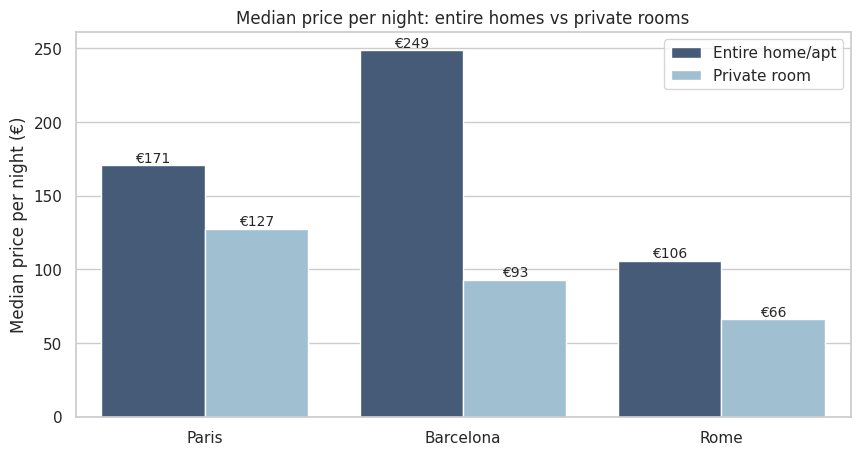

In [48]:
room_prices = airbnb.groupby(["city", "room_type"])["price_per_night"].median().unstack()
room_prices = room_prices.loc[city_order, room_order].round(1)
room_prices["entire_vs_private"] = (room_prices["Entire home/apt"] / room_prices["Private room"]).round(2)
print(room_prices)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=airbnb[airbnb["room_type"] != "Shared room"],
                 x="city", y="price_per_night", hue="room_type",
                 order=city_order, hue_order=room_order[:2], palette=ROOM_COLOURS,
                 estimator="median", errorbar=None)

for bar in ax.patches:
    if bar.get_height() > 0:
        ax.annotate(f"€{bar.get_height():.0f}",
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.title("Median price per night: entire homes vs private rooms")
plt.ylabel("Median price per night (€)")
plt.xlabel("")
plt.legend(title="")
plt.show()

**Observations:**

| City | Entire home | Private room | Shared room | Entire home costs... |
|---|---|---|---|---|
| Paris | €170.6 | €127.5 | €61.0 | 1.34 × a private room |
| Barcelona | **€248.8** | €93.1 | €55.5 | **2.67 ×** a private room |
| Rome | €106.0 | €66.3 | €51.9 | 1.60 × a private room |

- **Hypothesis H3 is confirmed:** in every city, entire homes cost more than private rooms, which cost more than shared rooms.
- **Barcelona's entire homes are the most expensive of all three cities**, even more than Paris (€249 vs €171). This is surprising, because Paris is the most expensive city overall (Section 8.1).
- **This explains Barcelona's two price groups from Section 6.1:** the hump around €90 is its many private rooms, and the hump around €250 is its fewer, pricier entire homes.
- **Why is Barcelona "cheap" overall?** Not because its listings are cheap, but because **80% of its listings are private rooms**. The overall median mostly reflects private rooms. If you want a whole apartment, Barcelona is actually the most expensive city.
- **Lesson:** an overall comparison between cities can hide what happens inside each group, because the cities have a different **mix** of room types. We explore this idea properly in Section 9 (Simpson's Paradox).
- In Paris, entire homes cost only 34% more than private rooms. Private rooms in Paris are expensive (€127.5), which suggests they are often in very central, high-demand areas.

**Q8.8 Do bigger listings (more bedrooms, more guests) cost more?**

Listings with 4, 5 or 6 bedrooms are very rare, so we group bedrooms into **0 (studio), 1, 2, and 3+**. `.clip(upper=3)` turns any value above 3 into 3, and `.map()` gives each number a label.

We also calculate the Spearman correlation (explained in 8.2) between price and both size columns.

bedrooms_group  0 (studio)      1      2     3+
city                                           
Paris                139.0  152.3  278.1  353.5
Barcelona            132.0   98.3  234.4  300.8
Rome                  91.2   84.2  118.8  147.5


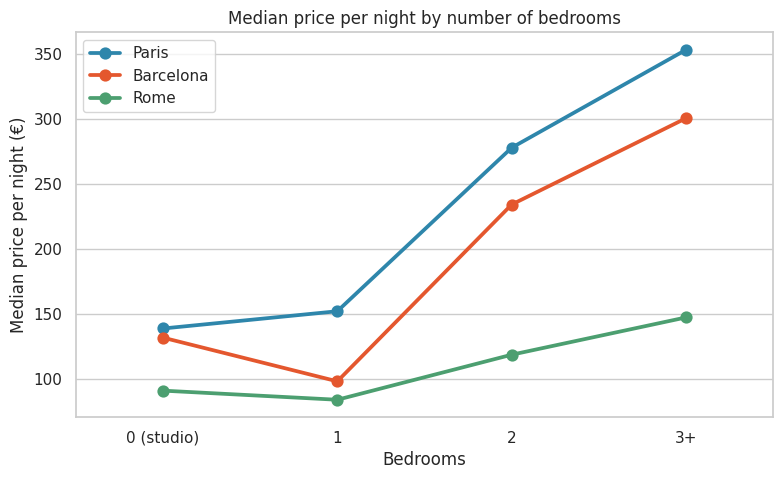


Spearman correlation with price:
                 Paris  Barcelona   Rome
bedrooms         0.353      0.419  0.362
person_capacity  0.518      0.572  0.518


In [49]:
airbnb["bedrooms_group"] = airbnb["bedrooms"].clip(upper=3).map({0: "0 (studio)", 1: "1", 2: "2", 3: "3+"})
bed_order = ["0 (studio)", "1", "2", "3+"]

bed_prices = airbnb.groupby(["city", "bedrooms_group"])["price_per_night"].median().unstack()
print(bed_prices.loc[city_order, bed_order].round(1))

plt.figure(figsize=(9, 5))
sns.pointplot(data=airbnb, x="bedrooms_group", y="price_per_night", hue="city",
              order=bed_order, hue_order=city_order, palette=CITY_COLOURS,
              estimator="median", errorbar=None)
plt.title("Median price per night by number of bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Median price per night (€)")
plt.legend(title="")
plt.show()

size_corr = pd.DataFrame(index=["bedrooms", "person_capacity"])
for city in city_order:
    city_data = airbnb[airbnb["city"] == city]
    size_corr[city] = [city_data["price_per_night"].corr(city_data[col], method="spearman")
                       for col in ["bedrooms", "person_capacity"]]
print("\nSpearman correlation with price:")
print(size_corr.round(3))

**Observations:**

| City | Studio | 1 bedroom | 2 bedrooms | 3+ bedrooms |
|---|---|---|---|---|
| Paris | €139.0 | €152.3 | €278.1 | €353.5 |
| Barcelona | €132.0 | €98.3 | €234.4 | €300.8 |
| Rome | €91.2 | €84.2 | €118.8 | €147.5 |

- **From 1 bedroom upwards, price rises clearly** in every city. In Paris, a 3+ bedroom listing costs more than twice a 1-bedroom listing.
- **Surprise: in Barcelona and Rome, 1-bedroom listings are cheaper than studios.** Why? When we checked, over 90% of **private rooms** are recorded as "1 bedroom" (the room itself), while studios are always **entire** apartments. So the "1 bedroom" group is full of cheaper private rooms. This is the same **mix effect** as before: the groups contain different types of listings.
- **Spearman correlations:**

| | Paris | Barcelona | Rome |
|---|---|---|---|
| `bedrooms` | 0.353 | 0.419 | 0.362 |
| `person_capacity` | **0.518** | **0.572** | **0.518** |

- **`person_capacity` has the strongest relationship with price of anything we have measured so far** (above 0.5 in every city, stronger than distance or attractions). Bigger listings for more guests cost more, even though every listing was priced for 2 guests.
- **Careful:** size and room type are connected (entire homes are usually bigger than private rooms), so part of this relationship comes from room type. We keep this in mind in Section 11.

We added one new column, `bedrooms_group`, so the table now has **18,543 rows and 25 columns**.

### **Summary of Component 3: Room Type & Size**
1. **Barcelona is mostly private rooms (81%); Paris is mostly entire homes (76%).**
2. **Entire homes cost more everywhere (H3 confirmed)**, and Barcelona's entire homes are the most expensive of all three cities.
3. Barcelona only looks cheap overall because of its **room-type mix**.
4. **Size, especially guest capacity, is the strongest single price driver we have found so far.**

### **8.4 Component 4: Hosts & Satisfaction**

**Q8.9 Do Superhosts charge more, and is that true in every city? Do they get better ratings?**

This tests **Hypothesis H5**, which we expected the data to **challenge**: we predicted Superhosts would have clearly better ratings but only a small or no price difference, because the badge rewards **service**, not luxury.

We compare, for each city:
- **Left chart:** the median price per night of Superhosts vs other hosts.
- **Right chart:** the average overall satisfaction of Superhosts vs other hosts. We use the **mean** here because ratings don't have extreme outliers like prices do.

**Note:** the right chart's y-axis starts at **80, not 0** (`set_ylim(80, 100)`), so the difference is easy to see. This makes the gap look bigger than it is, so we always read the actual numbers from the table.

Median price per night:
host_is_superhost  False   True  premium_%
city                                      
Paris              156.5  170.4        8.9
Barcelona          101.2  109.9        8.6
Rome                89.4   94.2        5.4

Average ratings:
                             cleanliness_rating  guest_satisfaction_overall
city      host_is_superhost                                                
Barcelona False                            9.17                       89.94
          True                             9.82                       96.42
Paris     False                            9.18                       91.30
          True                             9.78                       96.55
Rome      False                            9.35                       91.31
          True                             9.86                       96.85


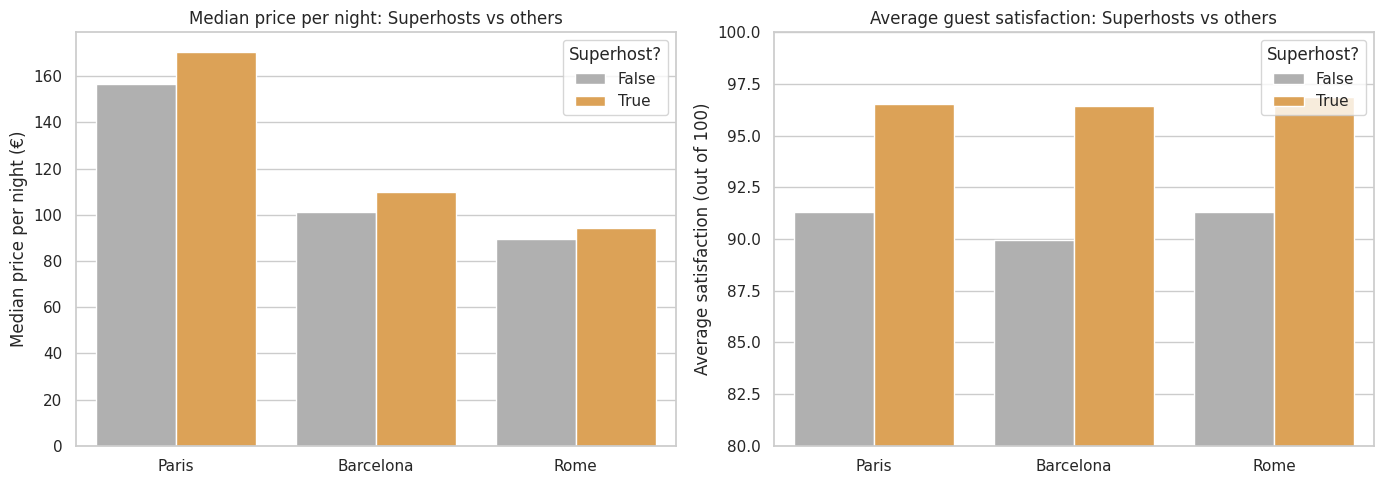

In [51]:
SUPERHOST_COLOURS = {False: "#B0B0B0", True: "#F2A541"}

superhost_price = airbnb.groupby(["city", "host_is_superhost"])["price_per_night"].median().unstack()
superhost_price = superhost_price.loc[city_order].round(1)
superhost_price["premium_%"] = ((superhost_price[True] - superhost_price[False])
                                / superhost_price[False] * 100).round(1)
print("Median price per night:")
print(superhost_price)

superhost_ratings = airbnb.groupby(["city", "host_is_superhost"])[
    ["cleanliness_rating", "guest_satisfaction_overall"]].mean().round(2)
print("\nAverage ratings:")
print(superhost_ratings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=airbnb, x="city", y="price_per_night", hue="host_is_superhost", order=city_order,
            palette=SUPERHOST_COLOURS, estimator="median", errorbar=None, ax=axes[0])
axes[0].set_title("Median price per night: Superhosts vs others")
axes[0].set_ylabel("Median price per night (€)")
axes[0].set_xlabel("")
axes[0].legend(title="Superhost?")

sns.barplot(data=airbnb, x="city", y="guest_satisfaction_overall", hue="host_is_superhost", order=city_order,
            palette=SUPERHOST_COLOURS, estimator="mean", errorbar=None, ax=axes[1])
axes[1].set_ylim(80, 100)
axes[1].set_title("Average guest satisfaction: Superhosts vs others")
axes[1].set_ylabel("Average satisfaction (out of 100)")
axes[1].set_xlabel("")
axes[1].legend(title="Superhost?")

plt.tight_layout()
plt.show()

**Observations:**

| City | Median price: others | Median price: Superhosts | Price premium | Satisfaction: others | Satisfaction: Superhosts |
|---|---|---|---|---|---|
| Paris | €156.5 | €170.4 | +8.9% | 91.3 | **96.6** |
| Barcelona | €101.2 | €109.9 | +8.6% | 89.9 | **96.4** |
| Rome | €89.4 | €94.2 | +5.4% | 91.3 | **96.9** |

- **Do Superhosts charge more everywhere?** Yes, but only **a little**: about 5% to 9% more in every city. The premium is smallest in Rome.
- **We checked whether this is just room type** (for example, if Superhosts had more entire homes). Even when comparing the same room type, Superhosts still charge slightly more. For example, Paris entire homes cost €186 with a Superhost vs €168 without. So the small premium is real.
- **The ratings difference is much clearer:** Superhosts score about **96 to 97** out of 100 in every city, vs about 90 to 91 for other hosts. Their cleanliness is also higher (about 9.8 vs 9.2 out of 10).
- **Hypothesis H5 behaved as we predicted:** "Superhosts charge noticeably more" is **not supported**. The price difference is small, while the ratings difference is large. The badge is about **service quality**, not a luxury price.
- **Rome has by far the most Superhosts:** about **33%** of its listings, compared with 18% in Barcelona and 14% in Paris.

**Q8.10 How do regular hosts (1 listing) compare with multi-listing and business hosts (5+ listings)?**

We use the `host_type` column from Section 5.2 and calculate, for each city and host type: the share of listings, the median price, the average satisfaction, and the percentage of Superhosts.

**How the code works:** `.agg()` with named results (`median_price=("price_per_night", "median")`) calculates several different things at once and gives each result a clear column name.

Share of listings by host type (%):
host_type  1 listing  2-4 listings  5+ listings
city                                           
Paris           53.5          22.0         24.6
Barcelona       29.0          38.6         32.4
Rome            28.0          38.6         33.4

Price, satisfaction and % Superhosts by host type:
                        median_price  mean_satisfaction  superhost_pct
city      host_type                                                   
Barcelona 1 listing             92.6               92.5           20.5
          2-4 listings          92.6               91.8           21.2
          5+ listings          163.2               89.1           12.5
Paris     1 listing            144.9               93.5           16.1
          2-4 listings         156.9               91.8           16.9
          5+ listings          192.2               89.0            7.2
Rome      1 listing             92.2               94.8           38.5
          2-4 listings          8

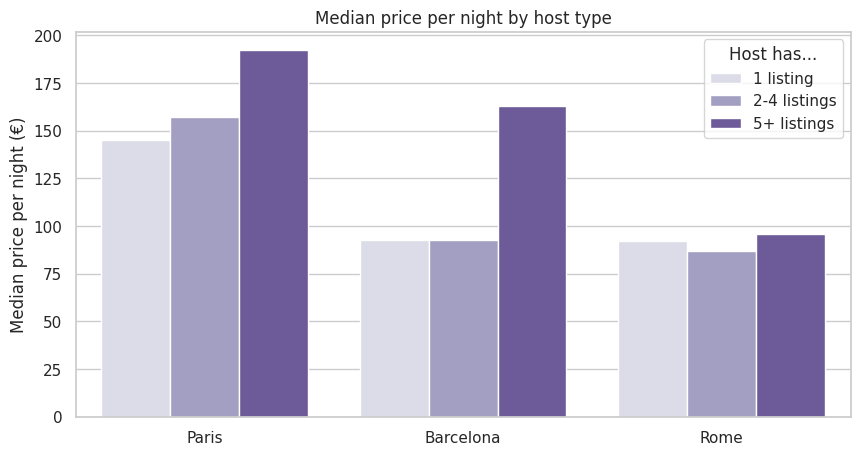

In [52]:
host_order = ["1 listing", "2-4 listings", "5+ listings"]

host_share = pd.crosstab(airbnb["city"], airbnb["host_type"], normalize="index") * 100
print("Share of listings by host type (%):")
print(host_share.loc[city_order, host_order].round(1))

host_summary = airbnb.groupby(["city", "host_type"]).agg(
    median_price=("price_per_night", "median"),
    mean_satisfaction=("guest_satisfaction_overall", "mean"),
    superhost_pct=("host_is_superhost", "mean")
)
host_summary["superhost_pct"] = host_summary["superhost_pct"] * 100
print("\nPrice, satisfaction and % Superhosts by host type:")
print(host_summary.round(1))

plt.figure(figsize=(10, 5))
sns.barplot(data=airbnb, x="city", y="price_per_night", hue="host_type", order=city_order,
            hue_order=host_order, palette="Purples", estimator="median", errorbar=None)
plt.title("Median price per night by host type")
plt.ylabel("Median price per night (€)")
plt.xlabel("")
plt.legend(title="Host has...")
plt.show()

**Observations:**

| City | 1 listing | 2-4 listings | 5+ listings (business) |
|---|---|---|---|
| **Share of listings** | | | |
| Paris | **53.5%** | 22.0% | 24.6% |
| Barcelona | 29.0% | 38.6% | 32.4% |
| Rome | 28.0% | 38.6% | 33.4% |
| **Median price** | | | |
| Paris | €144.9 | €156.9 | **€192.2** |
| Barcelona | €92.6 | €92.6 | **€163.2** |
| Rome | €92.2 | €86.7 | €95.6 |
| **Average satisfaction** | | | |
| Paris | 93.5 | 91.8 | **89.0** |
| Barcelona | 92.5 | 91.8 | **89.1** |
| Rome | 94.8 | 93.7 | **91.1** |

- **Paris is the only city where most listings belong to regular people** (53.5% have a host with just 1 listing). In Barcelona and Rome, **over 70% of listings belong to hosts with more than one listing**. Airbnb in these two cities is more of a **business**.
- **Business hosts charge the most** in Paris (€192 vs €145) and especially in Barcelona (€163 vs €93). In Barcelona this is partly because business hosts offer many more **entire homes** (42% of their listings, vs only about 9% for other hosts), and entire homes are the expensive type there (Section 8.3).
- In **Rome**, host type makes almost no difference to price.
- **Business hosts have the lowest satisfaction in every city** (about 89 to 91), and they are the least likely to be Superhosts (for example, only 7% in Paris). A person renting out their own home seems to give a more personal experience than a company managing many listings.

**Q8.11 Does cleanliness drive overall guest satisfaction?**

We calculate:
1. The **Spearman correlation** between cleanliness and overall satisfaction, for each city.
2. The **average satisfaction** for each cleanliness score, shown as a line chart, together with how many listings have each score.
3. For comparison, the correlation between **price** and both ratings, to see whether more expensive listings get better ratings.

Spearman correlations:
                             Paris  Barcelona   Rome
cleanliness vs satisfaction  0.615      0.649  0.612
price vs satisfaction        0.084      0.089  0.109
price vs cleanliness         0.094      0.116  0.055

Average satisfaction for each cleanliness score:
                    mean  count
cleanliness_rating             
2                   31.2     43
4                   56.7     35
5                   63.5     21
6                   70.1    178
7                   77.6    344
8                   84.4   1471
9                   90.6   5963
10                  95.9  10488


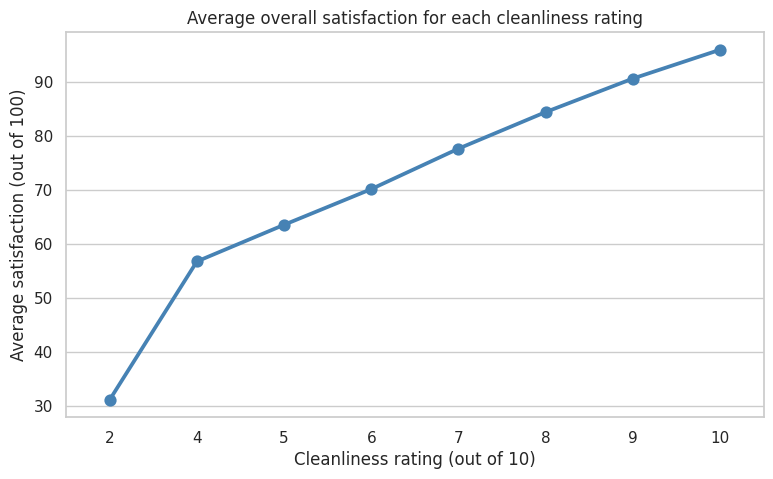

In [53]:
rating_corr = pd.DataFrame(index=["cleanliness vs satisfaction", "price vs satisfaction", "price vs cleanliness"])
for city in city_order:
    city_data = airbnb[airbnb["city"] == city]
    rating_corr[city] = [
        city_data["cleanliness_rating"].corr(city_data["guest_satisfaction_overall"], method="spearman"),
        city_data["price_per_night"].corr(city_data["guest_satisfaction_overall"], method="spearman"),
        city_data["price_per_night"].corr(city_data["cleanliness_rating"], method="spearman")
    ]
print("Spearman correlations:")
print(rating_corr.round(3))

clean_vs_sat = airbnb.groupby("cleanliness_rating")["guest_satisfaction_overall"].agg(["mean", "count"]).round(1)
print("\nAverage satisfaction for each cleanliness score:")
print(clean_vs_sat)

plt.figure(figsize=(9, 5))
sns.pointplot(data=airbnb, x="cleanliness_rating", y="guest_satisfaction_overall",
              estimator="mean", errorbar=None, color="steelblue")
plt.title("Average overall satisfaction for each cleanliness rating")
plt.xlabel("Cleanliness rating (out of 10)")
plt.ylabel("Average satisfaction (out of 100)")
plt.show()

**Observations:**

| Spearman correlation | Paris | Barcelona | Rome |
|---|---|---|---|
| Cleanliness vs satisfaction | **0.615** | **0.649** | **0.612** |
| Price vs satisfaction | 0.084 | 0.089 | 0.109 |
| Price vs cleanliness | 0.094 | 0.116 | 0.055 |

- **Cleanliness and satisfaction are strongly related** in every city (about 0.61 to 0.65). The line chart rises steadily: listings with a cleanliness score of **2** average only **31** satisfaction, while those with a **10** average **96**.
- **Careful with the lowest scores:** only 43 listings have a cleanliness score of 2, and only 21 have a 5, so those points are based on few listings. Most listings are at 9 or 10 (Section 6.3).
- **Correlation is not causation:** the same guests give both ratings after the same stay. A guest who had a bad experience overall might also rate cleanliness lower. So we can say they are **strongly linked**, but not prove that cleanliness **causes** higher satisfaction.
- **Price has almost no relationship with ratings** (all below 0.12). Paying more does **not** mean a better-rated stay. This fits the rating inflation from Section 6.3: almost everyone is rated 9 or 10, so ratings can't separate cheap and expensive listings.
- *(Pearson gives 0.69 for cleanliness vs satisfaction overall. Spearman is a bit lower because the ratings are bunched at the top, but both say the same thing: a strong positive relationship.)*

### **Summary of Component 4: Hosts & Satisfaction**
1. **Superhosts charge only about 5 to 9% more**, but get clearly better ratings (about 96 vs 91). H5 ("Superhosts charge noticeably more") is **not supported**, as we predicted.
2. **Paris is the only city where most listings are run by regular people.** In Barcelona and Rome, most listings belong to multi-listing or business hosts.
3. **Business hosts charge more** (in Paris and Barcelona) **but get the lowest ratings** in every city.
4. **Cleanliness is strongly linked to satisfaction**, but **price is not linked to ratings**.

### **8.5 Summary of Section 8: What drives Airbnb prices in the three cities?**

| Component | Main finding |
|---|---|
| **Price** | Paris is the most expensive (median €159 a night), then Barcelona (€104) and Rome (€91). Weekday and weekend prices are almost the same. |
| **Location** | Being near attractions and restaurants matters more than distance from the centre. Rome shows the clearest location effect, Barcelona the weakest. |
| **Room type & size** | The biggest price driver. Entire homes cost more everywhere, and guest capacity has the strongest correlation with price. Barcelona is 81% private rooms, which makes it look cheap overall. |
| **Hosts & satisfaction** | Superhosts charge only slightly more but are rated much higher. Business hosts charge more but are rated lowest. Ratings are not linked to price. |

**Hypotheses so far:**

| Hypothesis | Status after Section 8 |
|---|---|
| **H1** Weekends cost more in all three cities | **Not confirmed** at first look (differences within 3%). Checked more deeply in Sections 9 and 10. |
| **H2** Price falls with distance in all three cities | **Partly confirmed**: weakly negative everywhere, but not a smooth decline in Rome. |
| **H3** Entire homes > private rooms > shared rooms | **Confirmed** in every city. |
| **H4** Paris is the most expensive | **Confirmed.** |
| **H5** Superhosts charge noticeably more (expected to fail) | **Not supported**, as predicted: small premium, much better ratings. |

---
## **9. Relationships & Correlation**

In Section 8 we looked at one component at a time. Now we look at **how all the numeric columns relate to each other at once**, using a correlation matrix. Then we check for **Simpson's Paradox**: a trend that appears in combined data but disappears, or even reverses, when the data is split into groups.

### **9.1 Correlation matrix**

**Q9.1 Which columns are most strongly related to each other?**

A **correlation matrix** shows the correlation between every pair of columns in one table. A **heatmap** colours it: **red = positive**, **blue = negative**, **white = close to 0**. We use **Spearman** correlation, for the reasons explained in Section 8.2 (skewed prices).

**Columns we include:** all the numeric columns that describe a listing. True/False columns like `host_is_superhost` are treated as 1/0.

**Columns we leave out, and why:**
- `realSum` and `log_price`: they carry the same information as `price_per_night`.
- `attr_index_norm` and `rest_index_norm`: rescaled copies of the raw indices (Section 2.6).
- `lat` and `lng`: coordinates only mean something within one city's map, so they aren't useful numbers to correlate across cities.

**How the code works:** `annot=True` writes the number in each square, `fmt=".2f"` shows 2 decimals, and `vmin=-1, vmax=1` fixes the colour scale to the full correlation range.

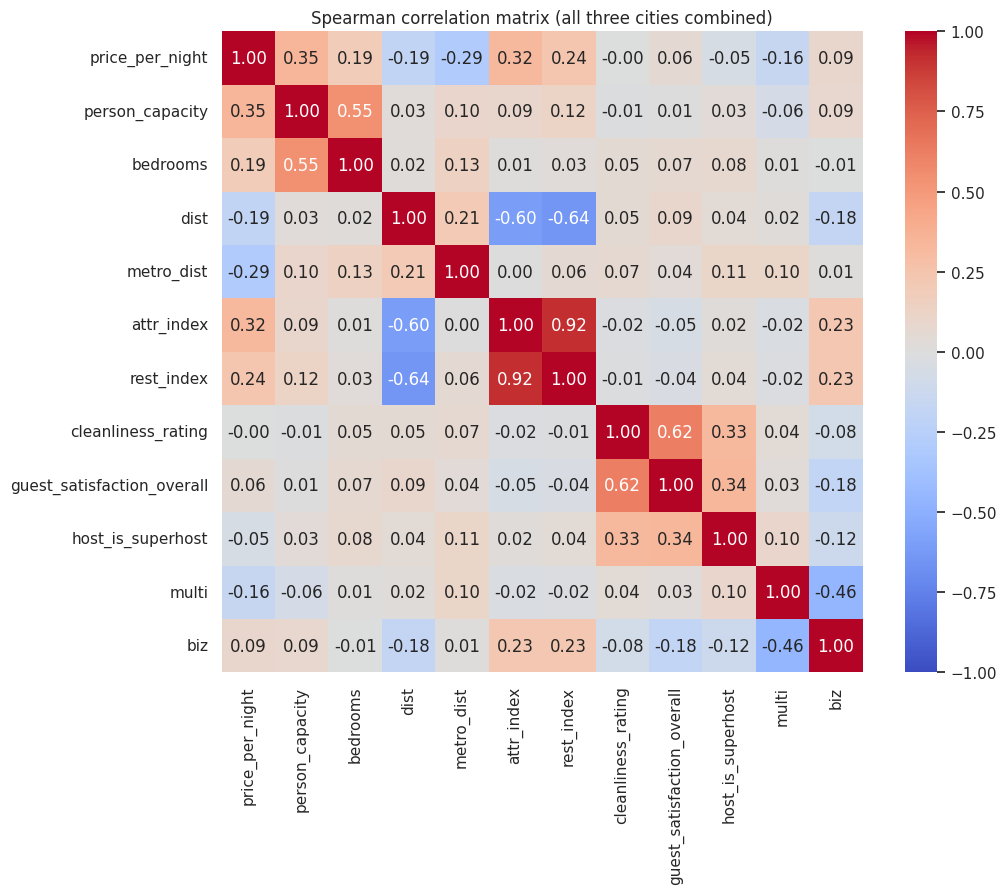

In [54]:
corr_cols = ["price_per_night", "person_capacity", "bedrooms", "dist", "metro_dist",
             "attr_index", "rest_index", "cleanliness_rating", "guest_satisfaction_overall",
             "host_is_superhost", "multi", "biz"]

corr_matrix = airbnb[corr_cols].corr(method="spearman")

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Spearman correlation matrix (all three cities combined)")
plt.tight_layout()
plt.show()

**Q9.2 What are the 5 strongest positive and 5 strongest negative correlations?**

**How the code works:** the matrix shows every pair **twice** (A with B, and B with A), and the diagonal is always 1 (each column with itself). `np.triu(..., k=1)` keeps only the **upper triangle** above the diagonal, so each pair appears once. `.stack()` turns the table into a list of pairs, `.dropna()` removes the empty cells, and `.sort_values()` sorts them from most negative to most positive.

In [55]:
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
pairs = upper.stack().dropna().sort_values()

print("5 strongest NEGATIVE correlations:")
print(pairs.head(5).round(2))
print("\n5 strongest POSITIVE correlations:")
print(pairs.tail(5).round(2))

5 strongest NEGATIVE correlations:
dist             rest_index   -0.64
                 attr_index   -0.60
multi            biz          -0.46
price_per_night  metro_dist   -0.29
                 dist         -0.19
dtype: float64

5 strongest POSITIVE correlations:
guest_satisfaction_overall  host_is_superhost             0.34
price_per_night             person_capacity               0.35
person_capacity             bedrooms                      0.55
cleanliness_rating          guest_satisfaction_overall    0.62
attr_index                  rest_index                    0.92
dtype: float64


**Observations:**

**Strongest positive correlations:**

| Pair | Value | Makes sense? | Could it be misleading? |
|---|---|---|---|
| `attr_index` & `rest_index` | **0.92** | Yes: tourist areas are full of both attractions and restaurants | They carry almost the **same information**, which is a problem for modelling (Section 11) |
| `cleanliness_rating` & `guest_satisfaction_overall` | 0.62 | Yes (Section 8.4) | Partly: the same guests give both ratings after the same stay |
| `person_capacity` & `bedrooms` | 0.55 | Yes: more bedrooms fit more guests | No, a genuine relationship |
| `price_per_night` & `person_capacity` | 0.35 | Yes: bigger listings cost more | Weaker than within each city (0.52 to 0.57 in Section 8.3), because mixing cities with different price levels blurs it |
| `guest_satisfaction_overall` & `host_is_superhost` | 0.34 | Yes | Partly **circular**: high ratings are one of the requirements for becoming a Superhost |

**Strongest negative correlations:**

| Pair | Value | Makes sense? | Could it be misleading? |
|---|---|---|---|
| `dist` & `rest_index` | **-0.64** | Yes: further from the centre means fewer restaurants | No |
| `dist` & `attr_index` | -0.60 | Yes: further from the centre means fewer attractions | No, but again overlapping information (Section 11) |
| `multi` & `biz` | -0.46 | **Built-in**: a host can't be both (Section 3.4), so when one is 1 the other must be 0 | Yes: this comes from how the columns were defined, not from real-world behaviour |
| `price_per_night` & `metro_dist` | -0.29 | Looks like "closer to metro = more expensive" | **Yes, misleading.** In Section 8.2 this was almost 0 within each city. We investigate in 9.2. |
| `price_per_night` & `dist` | -0.19 | Yes: further from the centre = cheaper | Weak, as found in Section 8.2 |

- **Price has no strong correlation with anything** (the highest is 0.35 with capacity). Price depends on **many factors together**, not on one single column.
- **Ratings are not correlated with price** (0.06 or less), as found in Section 8.4.

### **9.2 Simpson's Paradox, Example 1: Metro distance**

**Q9.3 With all cities combined, price and metro distance have a correlation of -0.29. Is that real?**

**Simpson's Paradox** happens when a relationship seen in **combined** data disappears or reverses when we look **within each group**. It happens when there is a hidden grouping variable, here the **city**.

We compare the correlation for all cities combined with the correlation inside each city, and then look at how metro distance and price differ between the cities.

`showfliers=False` hides the outlier dots in the box plots so we can compare the boxes themselves.

Spearman correlation between metro distance and price:
All cities combined   -0.291
Paris                 -0.045
Barcelona             -0.093
Rome                   0.102
dtype: float64


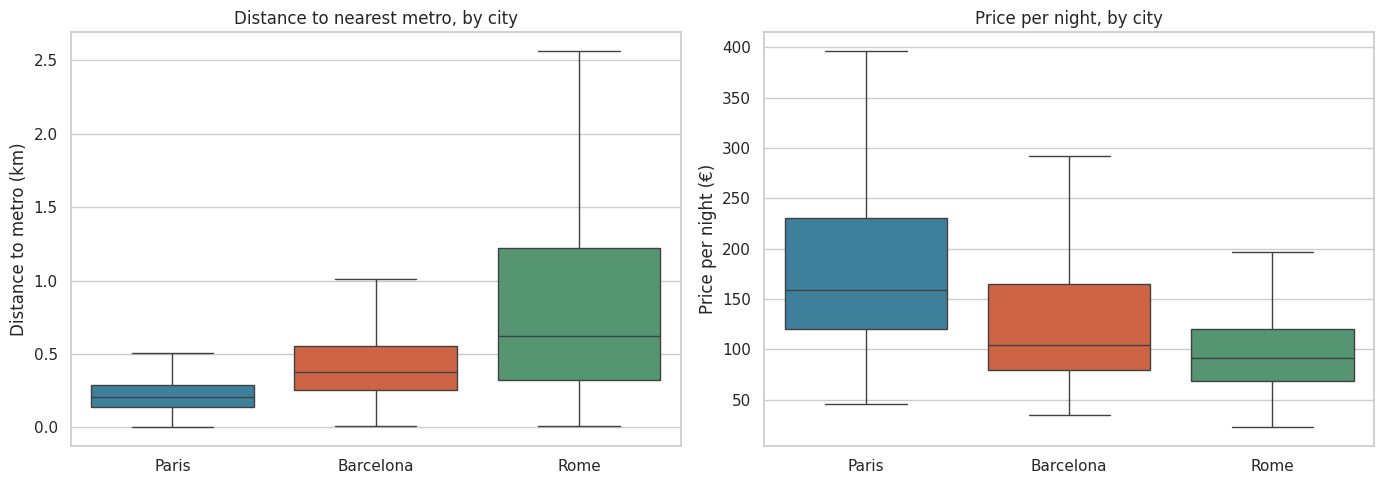

In [56]:
metro_corr = {"All cities combined": airbnb["metro_dist"].corr(airbnb["price_per_night"], method="spearman")}
for city in city_order:
    city_data = airbnb[airbnb["city"] == city]
    metro_corr[city] = city_data["metro_dist"].corr(city_data["price_per_night"], method="spearman")

print("Spearman correlation between metro distance and price:")
print(pd.Series(metro_corr).round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=airbnb, x="city", y="metro_dist", hue="city", order=city_order,
            palette=CITY_COLOURS, legend=False, showfliers=False, ax=axes[0])
axes[0].set_title("Distance to nearest metro, by city")
axes[0].set_ylabel("Distance to metro (km)")
axes[0].set_xlabel("")

sns.boxplot(data=airbnb, x="city", y="price_per_night", hue="city", order=city_order,
            palette=CITY_COLOURS, legend=False, showfliers=False, ax=axes[1])
axes[1].set_title("Price per night, by city")
axes[1].set_ylabel("Price per night (€)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**Observations:**

| | Correlation: metro distance vs price |
|---|---|
| **All cities combined** | **-0.291** |
| Paris | -0.045 |
| Barcelona | -0.093 |
| Rome | +0.102 |

- **This is Simpson's Paradox.** Combined, it looks like "the closer to a metro, the more expensive". But **inside every city the relationship is almost zero**, and in Rome it even points the other way.
- **Why?** The box plots show it:
  - **Paris** listings are the **closest** to a metro (median about 210 m) and are the **most expensive**.
  - **Rome** listings are the **furthest** from a metro (median about 620 m) and are the **cheapest**.
  - When the cities are mixed together, these **city differences** create a fake relationship. It's the **city** that affects price, not the metro distance.
- **Lesson:** a correlation calculated on combined data can be caused entirely by a hidden grouping variable. That's why we compared cities separately throughout Section 8.

### **9.3 Simpson's Paradox, Example 2: Barcelona weekends**

**Q9.4 In Section 8.1, Barcelona's weekends looked slightly cheaper than weekdays. Is that true for every type of listing?**

We compare Barcelona's median weekday and weekend price:
1. **Overall** (left chart)
2. **Separately for entire homes and private rooms** (right chart)

We leave out shared rooms (only 12 in Barcelona). `gridspec_kw={"width_ratios": [1, 2]}` makes the right chart twice as wide as the left, because it has twice as many bars.

Overall median price per night:
day_type
Weekdays    104.3
Weekends    102.9
Name: price_per_night, dtype: float64

Median price per night by room type:
day_type         Weekdays  Weekends  weekend_change_%
room_type                                            
Entire home/apt     237.2     266.0              12.1
Private room         92.6      95.7               3.3

Room type mix (%):
room_type  Entire home/apt  Private room
day_type                                
Weekdays              23.3          76.7
Weekends              14.0          86.0


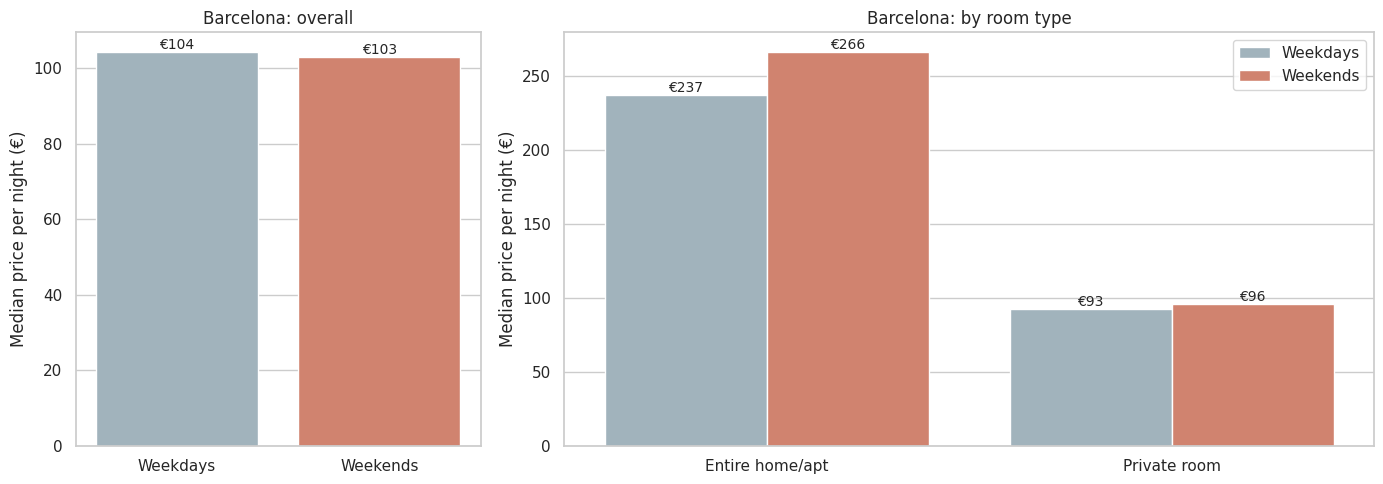

In [57]:
bcn = airbnb[(airbnb["city"] == "Barcelona") & (airbnb["room_type"] != "Shared room")]

print("Overall median price per night:")
print(bcn.groupby("day_type")["price_per_night"].median().round(1))

by_room = bcn.groupby(["room_type", "day_type"])["price_per_night"].median().unstack().round(1)
by_room["weekend_change_%"] = ((by_room["Weekends"] - by_room["Weekdays"]) / by_room["Weekdays"] * 100).round(1)
print("\nMedian price per night by room type:")
print(by_room)

room_mix = pd.crosstab(bcn["day_type"], bcn["room_type"], normalize="index") * 100
print("\nRoom type mix (%):")
print(room_mix.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})

sns.barplot(data=bcn, x="day_type", y="price_per_night", hue="day_type", palette=DAY_COLOURS,
            estimator="median", errorbar=None, legend=False, ax=axes[0])
axes[0].set_title("Barcelona: overall")
axes[0].set_ylabel("Median price per night (€)")
axes[0].set_xlabel("")

sns.barplot(data=bcn, x="room_type", y="price_per_night", hue="day_type", palette=DAY_COLOURS,
            estimator="median", errorbar=None, ax=axes[1])
axes[1].set_title("Barcelona: by room type")
axes[1].set_ylabel("Median price per night (€)")
axes[1].set_xlabel("")
axes[1].legend(title="")

for ax in axes:
    for bar in ax.patches:
        if bar.get_height() > 0:
            ax.annotate(f"€{bar.get_height():.0f}",
                        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

**Observations:**

| Barcelona | Weekdays | Weekends | Change |
|---|---|---|---|
| **Overall** | €104.3 | €102.9 | **-1.3%** (weekends cheaper) |
| Entire homes | €237.2 | €266.0 | **+12.1%** (weekends more expensive) |
| Private rooms | €92.6 | €95.7 | **+3.3%** (weekends more expensive) |

- **This is Simpson's Paradox.** Overall, weekends look slightly **cheaper**. But for **both** entire homes and private rooms, weekends are **more expensive**, by 12% for entire homes.
- **How can both be true?** The **room-type mix** is different in the two files:

| | Entire homes | Private rooms |
|---|---|---|
| Weekdays file | 23.3% | 76.7% |
| Weekends file | **14.0%** | **86.0%** |

- The weekend file contains far **fewer** entire homes (the expensive type). So even though each type costs more at weekends, the weekend group as a whole is **dominated by cheaper private rooms**, which drags its overall median down.
- **What this means for Hypothesis H1:** in Barcelona, **weekends DO cost more** once we compare like with like. The "no weekend premium" from Section 8.1 was misleading for Barcelona.
- **Other cities:** we ran the same check for Rome and Paris. In **Rome**, weekends are more expensive both overall and within each room type (no paradox). In **Paris**, weekends are slightly cheaper both overall and within each room type, so Paris genuinely shows **no weekend premium**.

### **9.4 Summary of Section 9**
1. **`attr_index` and `rest_index` are almost the same information** (0.92), and both overlap strongly with `dist`.
2. **Price has no single strong driver**; the strongest is guest capacity (0.35 combined, above 0.5 within each city).
3. **Simpson's Paradox appears twice:**
   - **Metro distance** looks linked to price only because of city differences.
   - **Barcelona weekends** look cheaper overall, but are more expensive for every room type.
4. **Lesson:** always check a combined result **within groups** (city, room type) before drawing a conclusion. The same lesson as `development_tier` in the Happiness × HDI lab.

---
## **10. Hypothesis Testing: Is the Difference Real or Just Chance?**

In Sections 8 and 9 we saw differences in **charts**, for example Rome's weekends costing 2.6% more. But even if weekends had no real effect on price, two random groups of listings would almost never have **exactly** the same median. So we ask: **is this difference big enough that it is unlikely to be just random chance?** A **statistical test** answers that.

**Key ideas:**
- **Null hypothesis (H₀):** "there is no real difference", e.g. weekday and weekend prices come from the same distribution.
- **Alternative hypothesis (H₁):** "there is a real difference".
- **p-value:** if there were really **no** difference, how likely is it that we would see a difference at least this big just by chance?
  - **Small p-value (below 0.05):** very unlikely to be chance, so we **reject H₀** and call the difference **statistically significant**.
  - **Large p-value (0.05 or above):** could easily be chance, so we **cannot** say there is a real difference.
- **0.05** is the standard cut-off (a 5% risk of calling something real when it's just chance).

**Important:** "significant" does **not** mean "big" or "important". With thousands of listings, even a tiny difference can be significant. So we always report the **size** of the difference (in € and %) next to the p-value.

### **10.1 Choosing the right test**

**Q10.1 Why do we use the Mann-Whitney U test instead of the t-test?**

- The **t-test** compares the **means** of two groups and assumes the data is roughly **normally distributed** (a symmetric bell curve).
- Our prices are **strongly right-skewed** (Section 6.1), so that assumption fails, and the mean is pulled by a few expensive listings anyway.
- The **Mann-Whitney U test** works like Spearman correlation: it replaces values with their **ranks** and checks whether one group tends to have **higher-ranked** values than the other. It doesn't need a normal distribution and isn't affected by extreme values.

We first confirm the skewness in each city:

In [58]:
for city in city_order:
    skew = airbnb[airbnb["city"] == city]["price_per_night"].skew()
    print(f"{city}: skewness of price = {skew:.2f}")

Paris: skewness of price = 4.51
Barcelona: skewness of price = 8.94
Rome: skewness of price = 5.85


**Answer:** Skewness is **4.51** in Paris, **8.93** in Barcelona and **5.85** in Rome, all far above 1. The prices are far from normal, so the **Mann-Whitney U test** is the right choice.

**A limitation we must state honestly:** the Mann-Whitney test assumes the two groups are **independent** (different listings in each). In Section 2.5 we found that **many listings appear in both the weekday and weekend files**. So the weekday and weekend groups are **not fully independent**, which can make the p-values look somewhat stronger than they really are. The Superhost comparison doesn't have this problem, because a listing is either a Superhost's or not.

### **10.2 Do weekends really cost more? (Hypothesis H1)**

**Q10.2 Is the weekday vs weekend price difference statistically significant, overall and within each room type, in each city?**

**How the code works:**
- `stats.mannwhitneyu(a, b, alternative="two-sided")` runs the test. "Two-sided" means we test for a difference in **either** direction (weekends higher **or** lower).
- We write a small function, `compare_groups`, that returns both medians and the p-value, so we don't repeat the same code.
- We run the test 9 times: for each city, on all listings, entire homes only, and private rooms only.
- p-values are shown in **scientific notation**: `2.70e-06` means 2.70 × 10⁻⁶ = 0.0000027, a very small number.

In [59]:
def compare_groups(group_a, group_b):
    stat, p = stats.mannwhitneyu(group_a, group_b, alternative="two-sided")
    return group_a.median(), group_b.median(), p

rows = []
for city in city_order:
    for room in ["All listings", "Entire home/apt", "Private room"]:
        data = airbnb[airbnb["city"] == city]
        if room != "All listings":
            data = data[data["room_type"] == room]

        weekdays = data[data["day_type"] == "Weekdays"]["price_per_night"]
        weekends = data[data["day_type"] == "Weekends"]["price_per_night"]
        wd_median, we_median, p = compare_groups(weekdays, weekends)

        rows.append({
            "city": city,
            "listings": room,
            "weekday_median": round(wd_median, 1),
            "weekend_median": round(we_median, 1),
            "change_%": round((we_median - wd_median) / wd_median * 100, 1),
            "p_value": f"{p:.2e}",
            "significant": p < 0.05
        })

weekend_tests = pd.DataFrame(rows)
weekend_tests

,city,listings,weekday_median,weekend_median,change_%,p_value,significant
0,Paris,All listings,159.3,158.1,-0.7,7.16e-01,False
1,Paris,Entire home/apt,172.7,169.8,-1.7,2.24e-01,False
2,Paris,Private room,128.9,127.3,-1.2,6.11e-01,False
3,Barcelona,All listings,104.3,101.8,-2.3,6.92e-01,False
4,Barcelona,Entire home/apt,237.2,266.0,12.2,2.70e-06,True
5,Barcelona,Private room,92.6,95.7,3.3,1.24e-03,True
6,Rome,All listings,89.9,92.2,2.6,1.56e-05,True
7,Rome,Entire home/apt,103.8,107.4,3.5,1.79e-03,True
8,Rome,Private room,64.5,67.6,4.7,1.15e-04,True


**Observations:**

| City | Listings | Weekday | Weekend | Change | p-value | Significant? |
|---|---|---|---|---|---|---|
| Paris | All | €159.3 | €158.1 | -0.7% | 0.716 | No |
| Paris | Entire homes | €172.7 | €169.8 | -1.7% | 0.224 | No |
| Paris | Private rooms | €128.9 | €127.3 | -1.2% | 0.611 | No |
| Barcelona | All | €104.3 | €101.8 | -2.3% | 0.692 | No |
| Barcelona | Entire homes | €237.2 | €266.0 | **+12.2%** | 0.0000027 | **Yes** |
| Barcelona | Private rooms | €92.6 | €95.7 | **+3.3%** | 0.0012 | **Yes** |
| Rome | All | €89.9 | €92.2 | **+2.6%** | 0.0000156 | **Yes** |
| Rome | Entire homes | €103.8 | €107.4 | **+3.5%** | 0.0018 | **Yes** |
| Rome | Private rooms | €64.5 | €67.6 | **+4.7%** | 0.00012 | **Yes** |

- **Paris:** no significant difference anywhere. **Paris has no weekend premium.**
- **Barcelona:** overall, **no** significant difference. But **within** both room types, weekends are **significantly more expensive**. The test confirms the **Simpson's Paradox** from Section 9.3: the weekend premium is real, and it is hidden in the overall number by the different room-type mix.
- **Rome:** weekends are significantly more expensive overall **and** within each room type.
- **Statistically significant but small:** Rome's weekend premium is real but only about **€2 to €3 a night**. Barcelona's entire homes are the only case with a **large** premium (about €29 a night, +12%).
- **Why the overlap limitation doesn't change our conclusions:** the significant p-values are all very small (0.0018 or less), far below 0.05, so they would stay significant even if the true p-values are somewhat larger. The Paris results are nowhere near significant either way.

**Final verdict on H1 ("weekends cost more in all three cities"): partly confirmed.** True in **Rome** and **Barcelona** (within each room type), but **not in Paris**.

### **10.3 Superhosts: price vs ratings (Hypothesis H5)**

**Q10.3 Are the Superhost differences in price and satisfaction statistically significant?**

We use the same `compare_groups` function, this time comparing **other hosts vs Superhosts**, for both price and overall satisfaction, in each city. `~data["host_is_superhost"]` selects the non-Superhosts (`~` means "not").

In [60]:
rows = []
for city in city_order:
    data = airbnb[airbnb["city"] == city]
    for col in ["price_per_night", "guest_satisfaction_overall"]:
        other_hosts = data[~data["host_is_superhost"]][col]
        superhosts = data[data["host_is_superhost"]][col]
        other_median, super_median, p = compare_groups(other_hosts, superhosts)

        rows.append({
            "city": city,
            "measure": col,
            "other_hosts_median": round(other_median, 1),
            "superhosts_median": round(super_median, 1),
            "p_value": f"{p:.2e}",
            "significant": p < 0.05
        })

superhost_tests = pd.DataFrame(rows)
superhost_tests

,city,measure,other_hosts_median,superhosts_median,p_value,significant
0,Paris,price_per_night,156.5,170.4,1.31e-04,True
1,Paris,guest_satisfaction_overall,93.0,97.0,1.92e-83,True
2,Barcelona,price_per_night,101.2,109.9,9.31e-04,True
3,Barcelona,guest_satisfaction_overall,91.0,97.0,1.08e-80,True
4,Rome,price_per_night,89.4,94.2,2.22e-12,True
5,Rome,guest_satisfaction_overall,93.0,97.0,4.81e-302,True


**Observations:**

| City | Measure | Other hosts | Superhosts | p-value | Significant? |
|---|---|---|---|---|---|
| Paris | Price per night | €156.5 | €170.4 | 0.00013 | Yes |
| Paris | Satisfaction | 93 | 97 | 1.92e-83 | Yes |
| Barcelona | Price per night | €101.2 | €109.9 | 0.00093 | Yes |
| Barcelona | Satisfaction | 91 | 97 | 1.08e-80 | Yes |
| Rome | Price per night | €89.4 | €94.2 | 2.22e-12 | Yes |
| Rome | Satisfaction | 93 | 97 | 4.81e-302 | Yes |

- **All differences are significant**, but look at **how** significant:
  - **Price** p-values are small (about 0.001 to 0.0000000000022).
  - **Satisfaction** p-values are unbelievably small (down to 10⁻³⁰²). The satisfaction difference is **far more certain and consistent** than the price difference.
- **Size of the differences:** Superhosts charge only **€5 to €14 more a night** (5 to 9%), but their median satisfaction is **4 to 6 points higher** in every city.

**Final verdict on H5 ("Superhosts charge noticeably more"):** Superhosts do charge **slightly** more, and that difference is statistically real, but it is **small**. The big, consistent difference is in **ratings**. So "noticeably more" is **not supported**, as we predicted: the badge reflects service, not price.

### **10.4 Are the three cities really different in price? (Hypothesis H4)**

**Q10.4 Is the price difference between Paris, Barcelona and Rome statistically significant?**

Mann-Whitney compares **two** groups. To compare **three** groups at once we use the **Kruskal-Wallis test**, the same rank-based idea extended to more than two groups. `*groups` passes the three city price lists into the function as three separate groups.

In [61]:
groups = [airbnb[airbnb["city"] == city]["price_per_night"] for city in city_order]
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis test: p-value = {p:.2e}")

Kruskal-Wallis test: p-value = 0.00e+00


**Answer:** The p-value is so small that it displays as **0** (smaller than the computer can show). The price levels of the three cities are **definitely different**, which statistically confirms **H4**: Paris (median €159) is the most expensive, ahead of Barcelona (€104) and Rome (€91).

### **10.5 Summary of Hypothesis Testing**

| Hypothesis | Test result | Final verdict |
|---|---|---|
| **H1** Weekends cost more in all 3 cities | Significant in Rome, and in Barcelona within each room type. Not significant in Paris. | **Partly confirmed** |
| **H4** Paris is the most expensive | Cities are significantly different (Kruskal-Wallis) | **Confirmed** |
| **H5** Superhosts charge noticeably more | Price premium significant but small; ratings difference huge | **Not supported** (as predicted) |

**Limitations of these tests:**
1. **The weekday and weekend groups overlap** (the same listings appear in both files), so they are not fully independent. Our significant results have very small p-values, so they are unlikely to change.
2. **Significant does not mean important:** Rome's weekend premium is real but only about €2 to €3 a night.
3. **We ran many tests.** The more tests you run, the higher the chance that one looks significant just by luck. Our significant results all have p-values below 0.002, far below 0.05, so this risk is low.

---
## **11. Leakage & Multicollinearity: Preparing for a Future Model**

We are **not** building a model in this project. But a good EDA should tell whoever builds one next **which columns are safe to use**. Imagine the goal is to **predict `price_per_night`** (the **target**) from the other columns (the **features**).

Two problems can ruin such a model:

**1. Data leakage:** a feature that contains the **answer** (the target) itself, or information that wouldn't be available at prediction time. The model looks excellent during testing, because it is effectively copying the answer, but it fails completely on new data.
*Example:* using `realSum` to predict `price_per_night`. The model just learns "divide by 2".

**2. Multicollinearity:** two or more features that carry **almost the same information**. The model can't tell which one is really responsible for the effect, so its results become unstable and hard to interpret.
*Example:* `attr_index` and `rest_index` (correlation 0.92, Section 9.1).

### **11.1 Checking for leakage**

**Q11.1 Which columns are built from the target itself?**

Three columns were created from price during our analysis. We check how strongly each one is correlated with `price_per_night`.

In [62]:
leak_check = airbnb[["price_per_night", "realSum", "log_price", "price_outlier"]].corr(method="spearman")
leak_check["price_per_night"].round(3)

,price_per_night
price_per_night,1.000
realSum,1.000
log_price,1.000
price_outlier,0.373


**Answer:**
- `realSum`: correlation **1.000**. It **is** the price, just for 2 nights instead of 1.
- `log_price`: correlation **1.000**. It's the log of the price (Spearman uses ranks, and taking a log doesn't change the order of values).
- `price_outlier`: correlation 0.373. It isn't a perfect copy, but it was **calculated from the price** (True if the price is above the city's upper fence, Section 7.3). A model given this column is being told "this listing is expensive" in advance.

**All three are leakage and must be excluded** when predicting price.

### **11.2 Checking for multicollinearity**

**Q11.2 Which pairs of features are strongly related to each other?**

We calculate the Spearman correlation between all candidate features (not including price) and list every pair with a correlation of **0.5 or more** (positive or negative). `.abs()` ignores the sign, so -0.64 counts as strong as well, and `sort_values(key=abs, ...)` sorts by strength regardless of sign.

In [63]:
feature_cols = ["person_capacity", "bedrooms", "dist", "metro_dist", "attr_index", "attr_index_norm",
                "rest_index", "rest_index_norm", "cleanliness_rating", "guest_satisfaction_overall",
                "host_is_superhost", "multi", "biz", "lat", "lng"]

feature_corr = airbnb[feature_cols].corr(method="spearman")
upper = feature_corr.where(np.triu(np.ones(feature_corr.shape, dtype=bool), k=1))
feature_pairs = upper.stack().dropna()

strong_pairs = feature_pairs[feature_pairs.abs() >= 0.5].sort_values(key=abs, ascending=False)
strong_pairs.round(2)

,,0
attr_index,rest_index,0.92
attr_index_norm,rest_index_norm,0.84
attr_index,attr_index_norm,0.78
rest_index,rest_index_norm,0.68
attr_index,rest_index_norm,0.66
dist,rest_index,-0.64
attr_index_norm,rest_index,0.63
cleanliness_rating,guest_satisfaction_overall,0.62
dist,attr_index,-0.60
person_capacity,bedrooms,0.55


**Answer:**

| Feature pair | Correlation | What it means |
|---|---|---|
| `attr_index` & `rest_index` | **0.92** | Almost the same information: tourist areas have both. **Keep one.** |
| `attr_index_norm` & `rest_index_norm` | 0.84 | Same issue, in their rescaled versions |
| `attr_index` & `attr_index_norm` | 0.78 | The same score, raw and rescaled (see below) |
| `rest_index` & `rest_index_norm` | 0.68 | The same score, raw and rescaled |
| `dist` & `rest_index` | -0.64 | Near the centre = more restaurants |
| `cleanliness_rating` & `guest_satisfaction_overall` | 0.62 | Given by the same guests after the same stay |
| `dist` & `attr_index` | -0.60 | Near the centre = more attractions |
| `person_capacity` & `bedrooms` | 0.55 | More bedrooms fit more guests |

**Why is `attr_index` vs `attr_index_norm` only 0.78 and not 1?** Within **one file**, the normalised score is an exact rescaling of the raw score (proved in Section 2.6), so the correlation would be exactly 1. But each of our 6 files was rescaled by its **own** maximum, so after combining the files, the same raw score can have different normalised values. That makes the normalised columns **unreliable** once the files are merged.

### **11.3 Exclusion list**

**Q11.3 If someone builds a model to predict `price_per_night`, which columns should they exclude, and why?**

| Column | Exclude? | Reason |
|---|---|---|
| `realSum` | **Exclude** | **Leakage:** it is the target × 2 |
| `log_price` | **Exclude** | **Leakage:** a transformation of the target. (It could replace `price_per_night` as the target, Section 6.1, but never be a feature.) |
| `price_outlier` | **Exclude** | **Leakage:** calculated from the target |
| `attr_index_norm`, `rest_index_norm` | **Exclude** | **Redundancy:** copies of the raw indices, rescaled differently in each file, so inconsistent after merging |
| `rest_index` | **Exclude** (keep `attr_index`) | **Multicollinearity:** 0.92 with `attr_index`. `attr_index` had an equal or stronger link with price in Section 8.2, so we keep that one. |
| `multi`, `biz` | **Exclude** (keep `host_type`) | **Redundancy:** `host_type` contains exactly the same information in one column (Section 5.2) |
| `dist_band` | **Exclude** (keep `dist`) | **Redundancy:** a grouped version of `dist`. Useful for charts, but a model should use the exact distance. |
| `bedrooms_group` | **Exclude** (keep `bedrooms`) | **Redundancy:** a grouped version of `bedrooms` |
| `lat`, `lng` | **Exclude as raw numbers** | Coordinates mean something only within each city's map. As raw numbers across three cities they don't describe location well; `dist`, `attr_index` and `city` already capture location. |
| `dist` & `attr_index` | **Keep both, but flag** | Moderate multicollinearity (-0.60). Watch this in linear models. |
| `person_capacity` & `bedrooms` | **Keep both, but flag** | Moderate multicollinearity (0.55). Both add some information about size. |

**Features that are safe to use:** `room_type`, `person_capacity`, `bedrooms`, `dist`, `metro_dist`, `attr_index`, `host_type`, `host_is_superhost`, `cleanliness_rating`, `guest_satisfaction_overall`, `city`, `day_type`.

### **11.4 Changing the target: predicting guest satisfaction**

**Q11.4 If instead we wanted to predict `guest_satisfaction_overall`, which features would become a problem?**

**Answer:** The leakage list changes, because it depends on **what** we predict.

- **`host_is_superhost` becomes leakage.** High guest ratings are one of the requirements for becoming a Superhost, so the badge is partly **built from** the target. A model would be learning the answer from a column that was created from it.
- **`cleanliness_rating` becomes risky.** It comes from the **same guests, in the same review, at the same time** as the overall rating. If the goal is to predict how satisfied guests will be with a new listing before anyone has stayed there, the cleanliness rating wouldn't exist yet. So it is information from the "future", which is also leakage.
- **Now safe to use:** `price_per_night` (no longer the target), `room_type`, `dist`, `attr_index`, `host_type`, `person_capacity` and `city`. These are all known **before** a guest stays.

The **same column** can be safe for one target and leakage for another. That's why the target must be decided before choosing features.

### **11.5 Why not just include everything?**

**Q11.5 A classmate says: "Just give the model all the columns and let it figure out which ones matter." What's wrong with that?**

**Answer:** A model cannot tell the difference between a column that genuinely **helps predict** the target and a column that **contains** the target. If we gave it `realSum`, it would score almost perfectly in testing by simply dividing by 2, and would be completely useless for pricing a new listing, where `realSum` is exactly the thing we don't know. Correlated columns like `attr_index` and `rest_index` would also split the credit between them, so the model's "feature importance" would say each matters only half as much as it really does, which misleads anyone reading it. Our EDA avoids this by deciding **before** modelling which columns are leakage (Section 11.1), which ones repeat the same information (11.2), and keeping one clear column for each idea (11.3).

### **11.6 Raw or rescaled? Linear or tree-based model?**

**Q11.6 We have both `attr_index` and `attr_index_norm`. Which should we keep? Does the answer depend on the type of model?**

**Answer:** Keep **`attr_index`** (raw) for both types of model, because the normalised version was rescaled separately in each file and is inconsistent after merging (11.2).

**Does the model type matter for multicollinearity?**
- **Linear models** (like linear regression) are **very sensitive** to multicollinearity. With two nearly identical features, the model can't decide how to split the effect between them, so their coefficients become unstable and meaningless. **We must drop one of each strongly correlated pair.**
- **Tree-based models** (like decision trees and random forests) are **less affected** in their predictions: they simply pick whichever feature splits the data best. But their **feature importance** still gets split between correlated features, which is misleading. So it's still better to keep one clear column per idea.

### **11.7 Summary**
1. **Leakage (exclude):** `realSum`, `log_price` and `price_outlier`, all built from the price itself.
2. **Redundancy (keep one):** raw vs normalised indices, `multi`/`biz` vs `host_type`, and binned vs exact columns.
3. **Multicollinearity:** `attr_index` and `rest_index` are almost identical (0.92), so keep `attr_index`. Flag `dist` & `attr_index`, and `person_capacity` & `bedrooms`.
4. **Leakage depends on the target:** if predicting satisfaction, `host_is_superhost` and `cleanliness_rating` become leakage.

---
## **12. Final Report**

This report summarises the whole project for a reader who has not seen the rest of the notebook. Every number here comes from the sections referenced in brackets.



### **12.1 Dataset Overview**

- **Source:** Airbnb price data collected by Gyódi & Nawaro (University of Warsaw) for a 2021 research paper, downloaded from Kaggle.
- **What we used:** 6 files: weekday and weekend listings for **Paris, Rome and Barcelona**.
- **What one row means:** one Airbnb listing's price for **2 guests staying 2 nights**, in euros.
- **Merge:** the files have no listing ID, so they were **stacked** (`pd.concat`) rather than joined, with `city` and `day_type` labels added. **All 18,548 rows were kept** in the merge (Section 4).
- **Final dataset:** **18,543 rows** after removing 5 rows with suspicious placeholder prices (Section 7).
- **City sizes are unequal:** Rome 49%, Paris 36%, Barcelona 15% of rows, so every comparison was made **city by city** (Section 2.2).

### **12.2 Data Quality Findings**

- **No missing values and no duplicate rows** in any file (Sections 3.1, 3.3).
- **Hidden missingness (selection bias, closest to MNAR):** there are **no listings for 1 guest**, because the researchers searched for 2 guests. Listings without reviews were probably not included either. Our results describe listings for **2 or more guests** (Section 3.2).
- **The same listing can appear in both the weekday and weekend files**, as two different bookings. These are not duplicates, but the two groups are **not fully independent** (Sections 2.5, 10.1).
- **Redundant columns:** `room_shared` and `room_private` are exact copies of `room_type` (dropped, Section 4.4). `attr_index_norm` and `rest_index_norm` are the raw indices rescaled **per file**, which makes them inconsistent after merging (Sections 2.6, 11.2).
- **No encoding problems:** `room_type` is spelled identically in every file (Section 3.5).
- **Low ratings (20/100, 2/10) are valid:** they equal 1 star on Airbnb's 1 to 5 star scale (Section 3.6).

### **12.3 Key Distribution Findings**

1. **Price is extremely right-skewed** (skewness 18). A log transformation brings it close to a bell curve (skewness 0.68). The **median** is the fair "typical price" (Sections 6.1, 6.2).
2. **Ratings are inflated:** 88.7% of listings score 9 or 10 for cleanliness. Ratings have very little variation, which limits what they can explain (Section 6.3).
3. **Groups are unbalanced:** shared rooms are only 0.6% of listings (too few to compare reliably), and only 24% of listings belong to Superhosts (Section 6.4).

### **12.4 Answers to our Problem Statements**

| # | Question (Section 0.4) | Answer |
|---|---|---|
| 1 | Which city is most expensive? | **Paris** (median €159 a night), then Barcelona (€104) and Rome (€91). Paris costs 53% more than Barcelona and 74% more than Rome. |
| 2 | Do weekends cost more? | **Rome: yes** (+2.6%). **Barcelona: yes within each room type** (+12% entire homes, +3% private rooms), although the overall figure hides it (Simpson's Paradox). **Paris: no.** |
| 3 | Does price fall with distance from the centre? | **Weakly** (correlation about -0.22 to -0.29), similarly in all three cities. Not a smooth decline in Rome. |
| 4 | Are listings near attractions and restaurants more expensive? | **Yes, and this matters more than distance:** correlation 0.52 in Rome and 0.46 in Paris for attractions. Weakest in Barcelona (0.29). |
| 5 | What kind of accommodation dominates? | **Paris: 76% entire homes. Barcelona: 81% private rooms.** Rome: 62% entire homes. |
| 6 | How much more does an entire home cost? | 1.34 × a private room in Paris, 1.60 × in Rome, and **2.67 × in Barcelona**, where entire homes are the most expensive of all three cities (€249 a night). |
| 7 | Do Superhosts charge more? | **Only 5 to 9% more**, but their satisfaction is much higher (about 96 to 97 vs 90 to 91). |
| 8 | Are business hosts rated differently? | **Yes, lowest satisfaction in every city** (about 89 to 91). They also charge the most in Paris and Barcelona. |
| 9 | Does cleanliness drive satisfaction? | **Strongly linked** (0.61 to 0.65), though not proven to be the cause. **Price is not linked to ratings.** |

### **12.5 Hypotheses: Final Verdicts**

| Hypothesis (Section 1, PA5) | Verdict | Evidence |
|---|---|---|
| **H1** Weekends cost more in all three cities | **Partly confirmed** | True in Rome and in Barcelona (within room types); false in Paris (Sections 8.1, 9.3, 10.2) |
| **H2** Price falls with distance in all three cities | **Partly confirmed** | Weakly negative in all cities, but not a smooth decline in Rome (Section 8.2) |
| **H3** Entire homes > private rooms > shared rooms | **Confirmed** | True in every city (Section 8.3) |
| **H4** Paris is the most expensive | **Confirmed** | Highest median; city differences significant (Sections 8.1, 10.4) |
| **H5** Superhosts charge noticeably more *(expected to fail)* | **Not supported, as predicted** | Small premium (5 to 9%), large ratings difference (Sections 8.4, 10.3) |

**The biggest surprise:** we expected weekends to be more expensive everywhere, but the overall numbers showed almost no difference. Only by splitting by room type did we find the real weekend premium in Barcelona.

### **12.6 Key Relationship Findings**

**Feature and price:**
1. **Guest capacity** is the strongest single driver of price (0.52 to 0.57 within each city) (Section 8.3).
2. **Room type** creates the biggest price gaps, especially in Barcelona (Section 8.3).
3. **Nearby attractions** matter more than distance from the centre (Section 8.2).

**Feature and feature:**
1. `attr_index` and `rest_index` are almost identical (0.92) (Section 9.1).
2. `dist` is strongly related to both indices (-0.60 and -0.64) (Section 9.1).
3. `cleanliness_rating` and `guest_satisfaction_overall` are strongly linked (0.62) (Section 9.1).

**Simpson's Paradox (found twice):**
- **Metro distance** looks linked to price (-0.29) only when cities are combined. Inside each city the relationship is about zero, because Paris listings are both closest to a metro and most expensive (Section 9.2).
- **Barcelona weekends** look cheaper overall but are more expensive for every room type, because the weekend file contains far fewer entire homes (14% vs 23%) (Section 9.3).

### **12.7 Outlier Decisions**

| Outliers | Type | Decision |
|---|---|---|
| 1,046 listings above their city's IQR fence | Statistical, but real (mostly large, central entire homes) | **Kept and flagged** (`price_outlier`) |
| Large luxury listings (e.g. 6 bedrooms at €2,234 a night) | Statistical, but believable | **Kept** |
| 5 rows: 1-bedroom, 2-guest flats above €3,000 a night (1 in Paris, 4 in Barcelona) | Statistical **and** domain: likely placeholder prices | **Removed** |

IQR had to be calculated **per city**: one combined fence would have flagged 909 Paris listings just for being in Paris (Section 7.2).

### **12.8 Leakage and Exclusion List (for a model predicting price)**

| Excluded column | Reason |
|---|---|
| `realSum`, `log_price`, `price_outlier` | **Leakage:** built from the price itself |
| `attr_index_norm`, `rest_index_norm` | **Redundancy:** rescaled per file, inconsistent after merging |
| `rest_index` | **Multicollinearity:** 0.92 with `attr_index` |
| `multi`, `biz` | **Redundancy:** replaced by `host_type` |
| `dist_band`, `bedrooms_group` | **Redundancy:** grouped versions of `dist` and `bedrooms` |
| `lat`, `lng` (as raw numbers) | Only meaningful within one city's map |

If the target were **satisfaction** instead, `host_is_superhost` and `cleanliness_rating` would also become leakage (Section 11.4).

### **12.9 Recommended Preprocessing Steps**

Based on everything above, before building a price model:

1. **Target:** use `log_price` instead of `price_per_night`, because price is extremely skewed.
2. **Drop** the columns in the exclusion list (12.8).
3. **No imputation needed:** there are no missing values.
4. **Encode categories:** turn `room_type`, `city`, `day_type` and `host_type` into numbers (e.g. one-hot encoding), and convert `host_is_superhost` from True/False to 1/0.
5. **Scale numeric features** (`dist`, `attr_index`, `person_capacity`, etc.) if using a linear model. Tree-based models don't need this.
6. **Shared rooms (0.6%):** too few to learn from. Either drop them or clearly mention the limitation.
7. **Train/test split:** split **by city** in the same proportions, so Rome doesn't dominate the test set. Also, because the **same listing can appear in both files**, make sure it doesn't end up in both the training and test sets. Otherwise the model is tested on listings it has already seen, which is another form of leakage.
8. **Use `price_outlier`** only to check whether results change with and without outliers, **never as a feature**.

### **12.10 Limitations**

1. **The sample isn't all of Airbnb:** only listings bookable for 2 guests (and probably only listings with reviews).
2. **Prices may be outdated:** the data was collected for a 2021 study, and prices have likely changed since.
3. **No dates or seasons:** we can only compare "weekday" vs "weekend", not summer vs winter or holidays.
4. **No listing ID:** we could not track the same listing across files, and the weekday and weekend groups overlap.
5. **Correlation is not causation:** for example, we showed cleanliness and satisfaction are linked, not that one causes the other.
6. **The exact formula for `attr_index` and `rest_index`** comes from the researchers' paper; we used them as provided.
7. **Only 3 cities:** the findings may not apply to other European cities.

### **12.11 Conclusion**

Airbnb prices in Paris, Rome and Barcelona are driven mainly by **what you get** (room type and size) and **where it is** (near attractions and restaurants), much more than by the day of the week or the host's Superhost badge. **Paris is clearly the most expensive city**, while **Barcelona only looks cheap** because 4 out of 5 of its listings are private rooms. For an entire apartment, Barcelona is actually the most expensive of the three.

The most important lesson from this project is methodological: **overall numbers can mislead.** Twice we found a result in the combined data that disappeared or reversed once we looked inside each city or room type (Simpson's Paradox). Checking results **within groups** before drawing conclusions was essential to getting the right answer.